
  Device  : CUDA
  PyTorch : 2.9.0+cu126
  obs_dim = 18   joint_dim = 16

  ════════════════════════════════════════════════════════════════════════════
  QR-DQN  ·  Centralised Training / Decentralised Execution
  3 Elevators  ·  10 Floors  ·  Seed 42
  Non-Uniform Traffic  (Lobby x5, λ = 0.12 – 0.35)  ·  CUDA  ·  PyTorch 2.9.0+cu126
  ════════════════════════════════════════════════════════════════════════════

  obs_dim = 18   joint_dim = 16


  ┌──────────────────────────────────────────────────────────────────────────┐
  │  Baseline Evaluation  (30 episodes x 300 steps)                            │
  └──────────────────────────────────────────────────────────────────────────┘

  Evaluating Nearest Car            ...  wait = 9.68   energy = 410   cluster = 98.5%
  Evaluating SCAN / LOOK            ...  wait = 1.42   energy = 900   cluster = 98.5%
  Evaluating ETA-Dispatch           ...  wait = 0.67   energy = 473   cluster = 10.2%
  Evaluating Sectoring              ...  wait = 0.

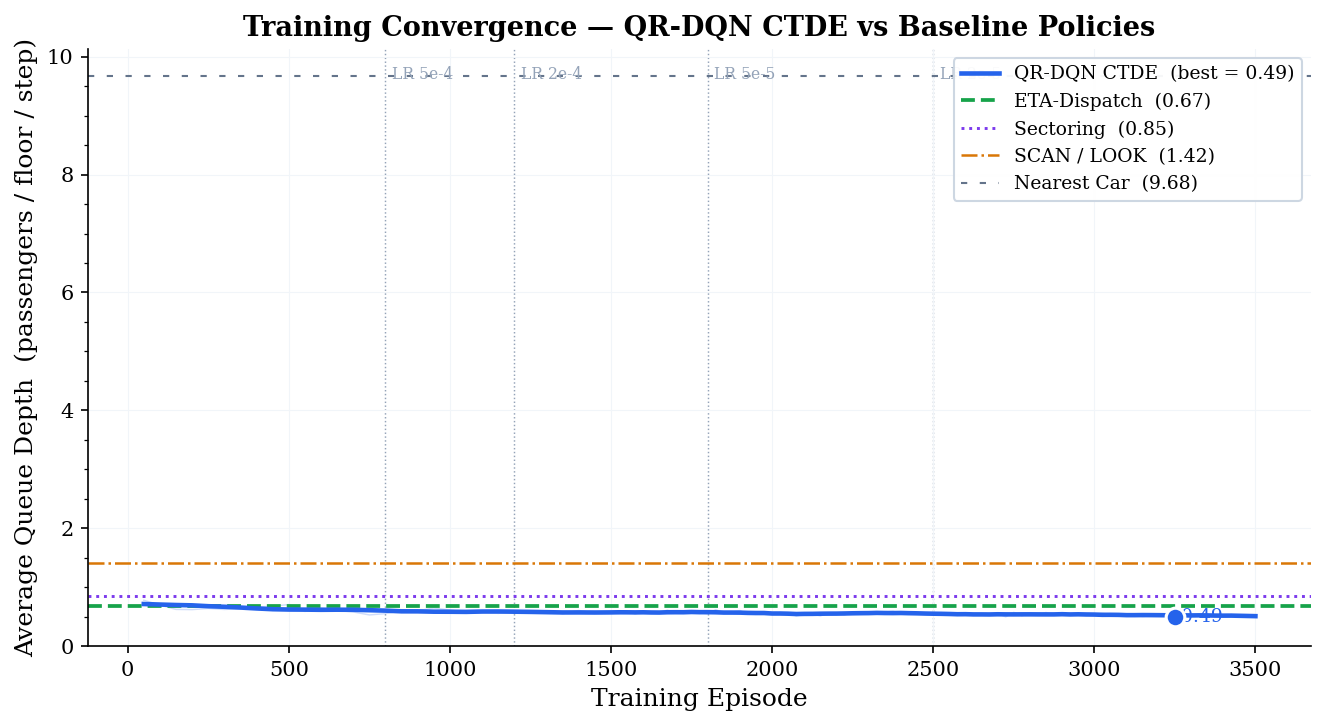

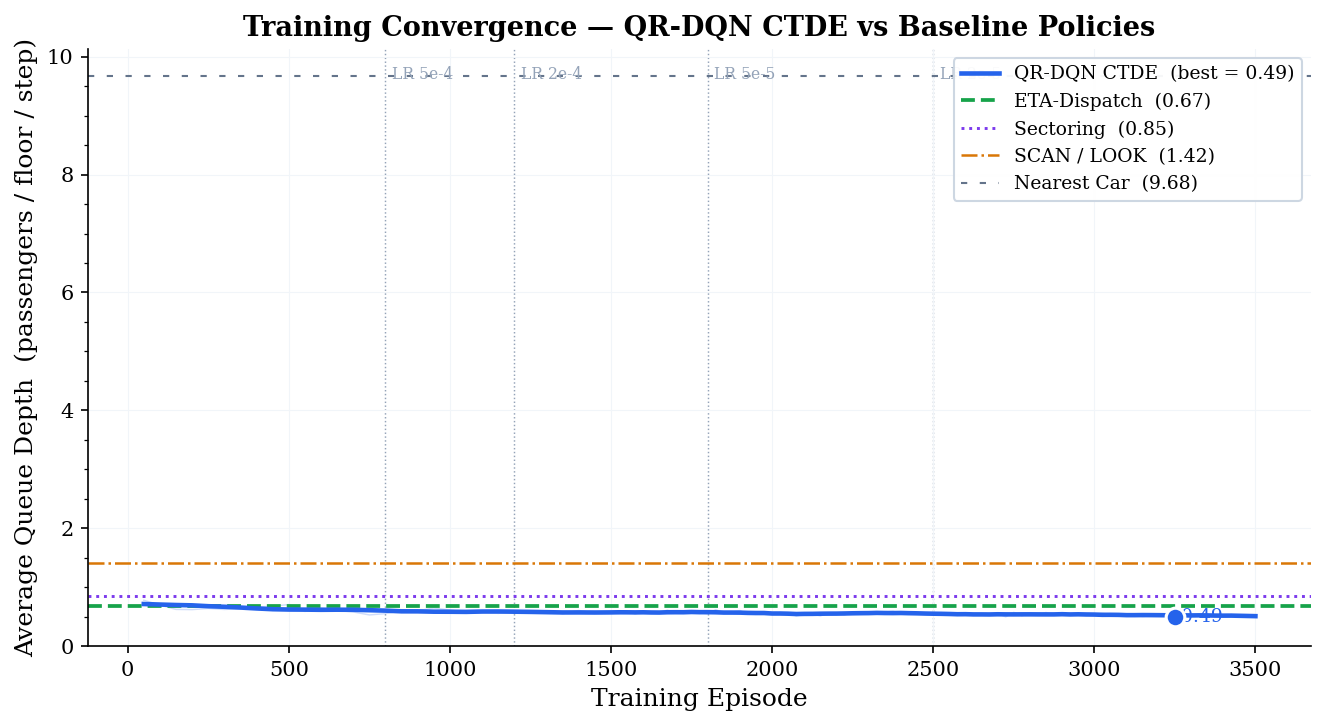

  Figure 2: Composite Score
    PNG  ->  /kaggle/working/elevator_qrdqn_n3_seed42_fig2_composite_score.png  (284 KB)
    PDF  ->  /kaggle/working/elevator_qrdqn_n3_seed42_fig2_composite_score.pdf  (25 KB)
    PNG  ->  /content/elevator_qrdqn_n3_seed42_fig2_composite_score.png  (284 KB)
    PDF  ->  /content/elevator_qrdqn_n3_seed42_fig2_composite_score.pdf  (25 KB)


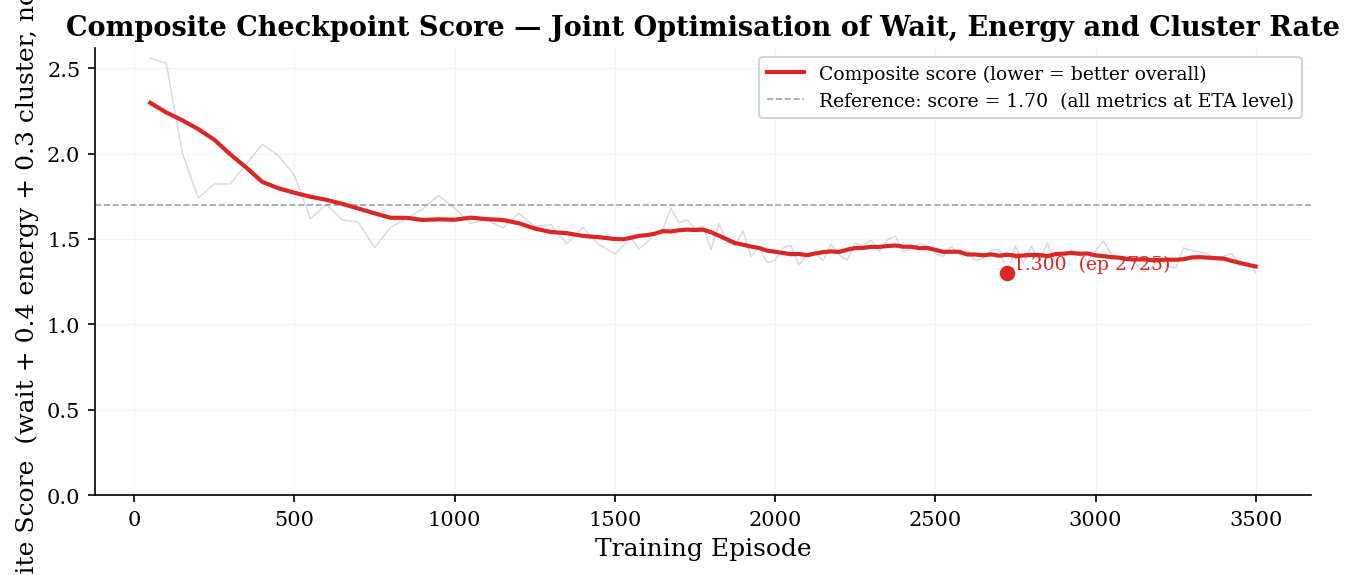

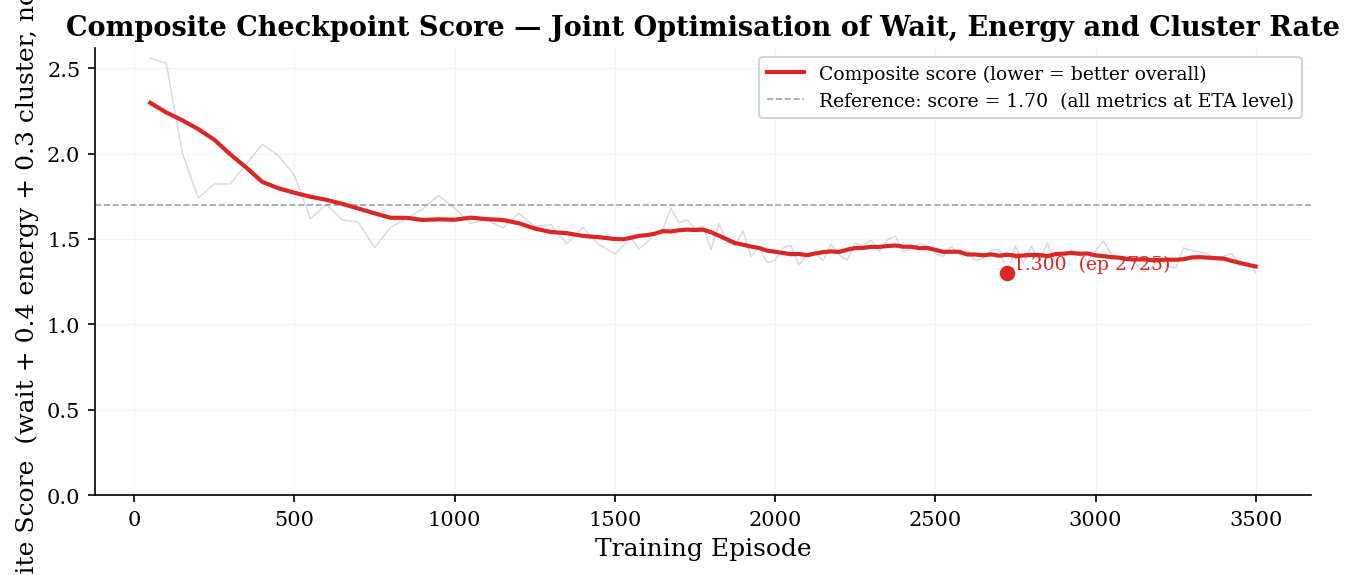

  Figure 3: Wait Time Comparison
    PNG  ->  /kaggle/working/elevator_qrdqn_n3_seed42_fig3_wait.png  (199 KB)
    PDF  ->  /kaggle/working/elevator_qrdqn_n3_seed42_fig3_wait.pdf  (22 KB)
    PNG  ->  /content/elevator_qrdqn_n3_seed42_fig3_wait.png  (199 KB)
    PDF  ->  /content/elevator_qrdqn_n3_seed42_fig3_wait.pdf  (22 KB)


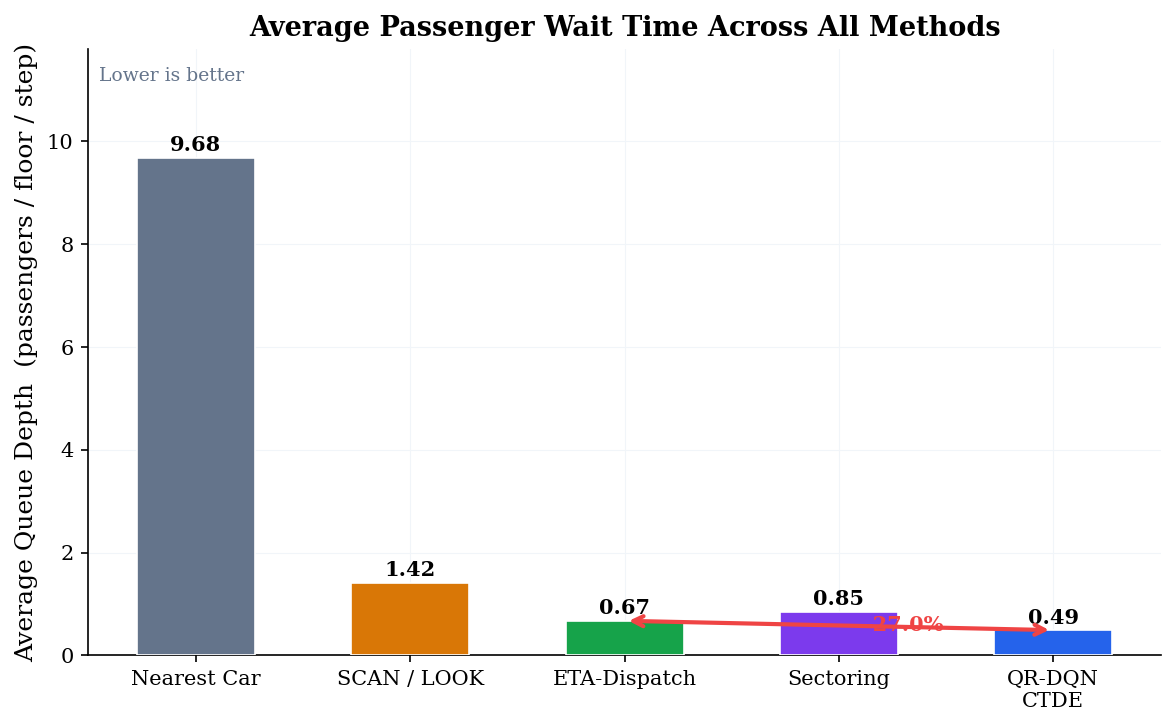

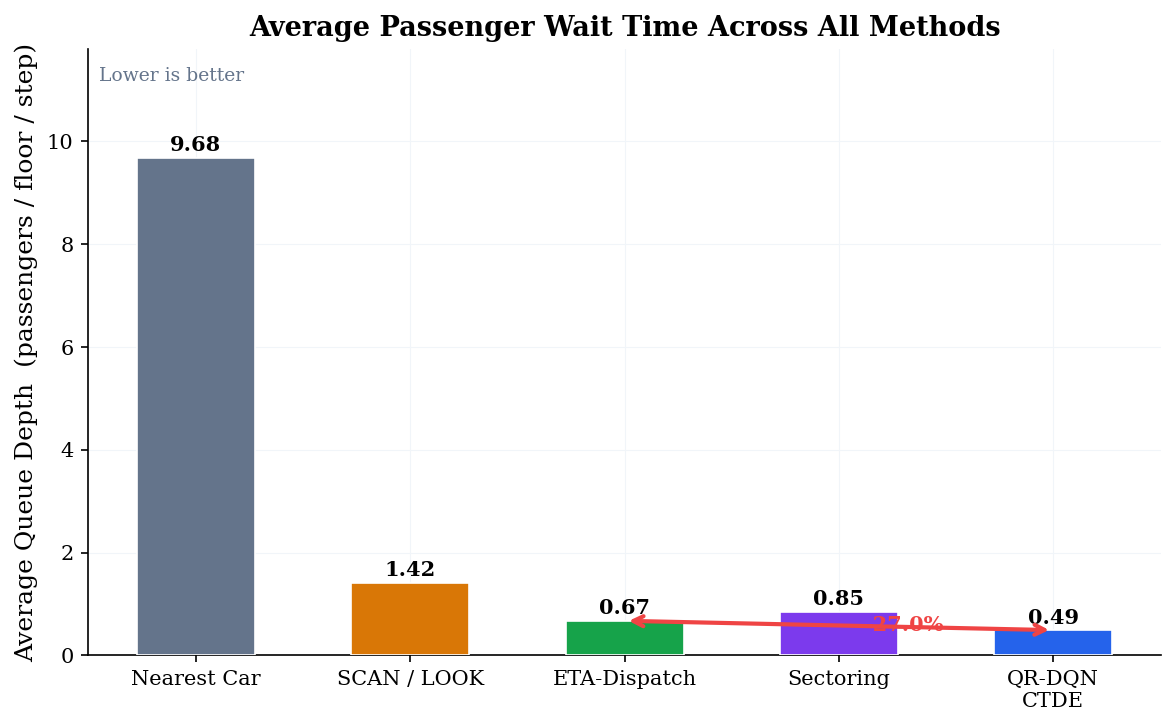

  Figure 4: Energy Consumption
    PNG  ->  /kaggle/working/elevator_qrdqn_n3_seed42_fig4_energy.png  (180 KB)
    PDF  ->  /kaggle/working/elevator_qrdqn_n3_seed42_fig4_energy.pdf  (21 KB)
    PNG  ->  /content/elevator_qrdqn_n3_seed42_fig4_energy.png  (180 KB)
    PDF  ->  /content/elevator_qrdqn_n3_seed42_fig4_energy.pdf  (21 KB)


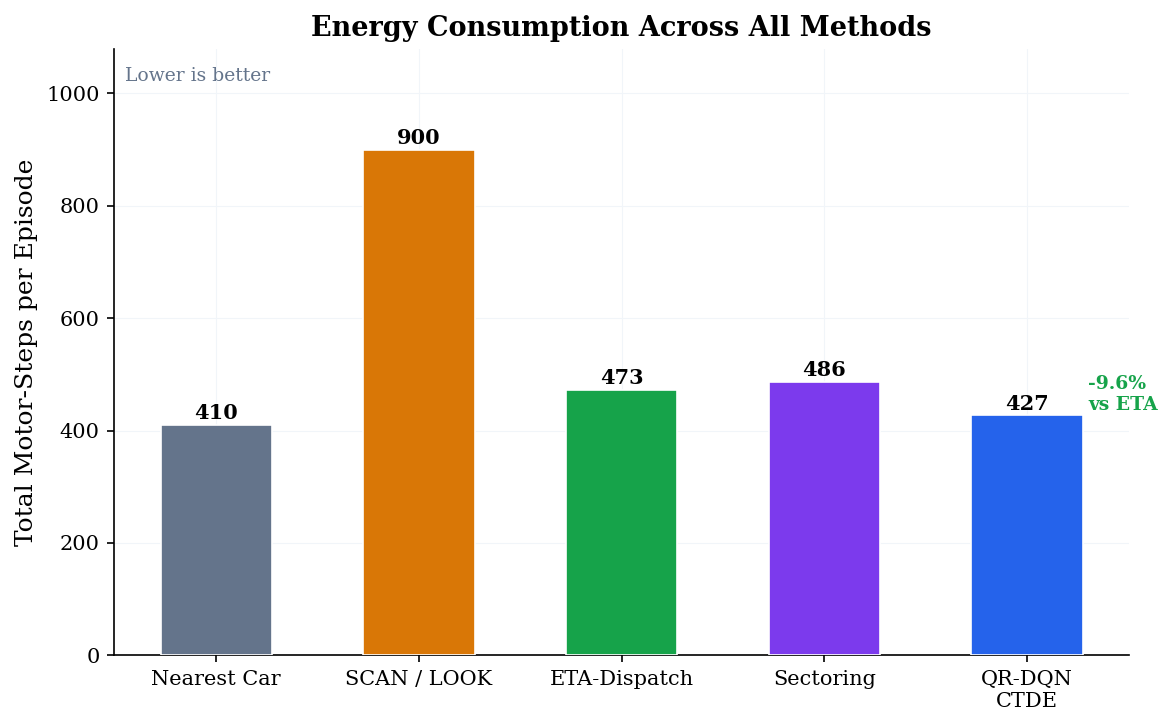

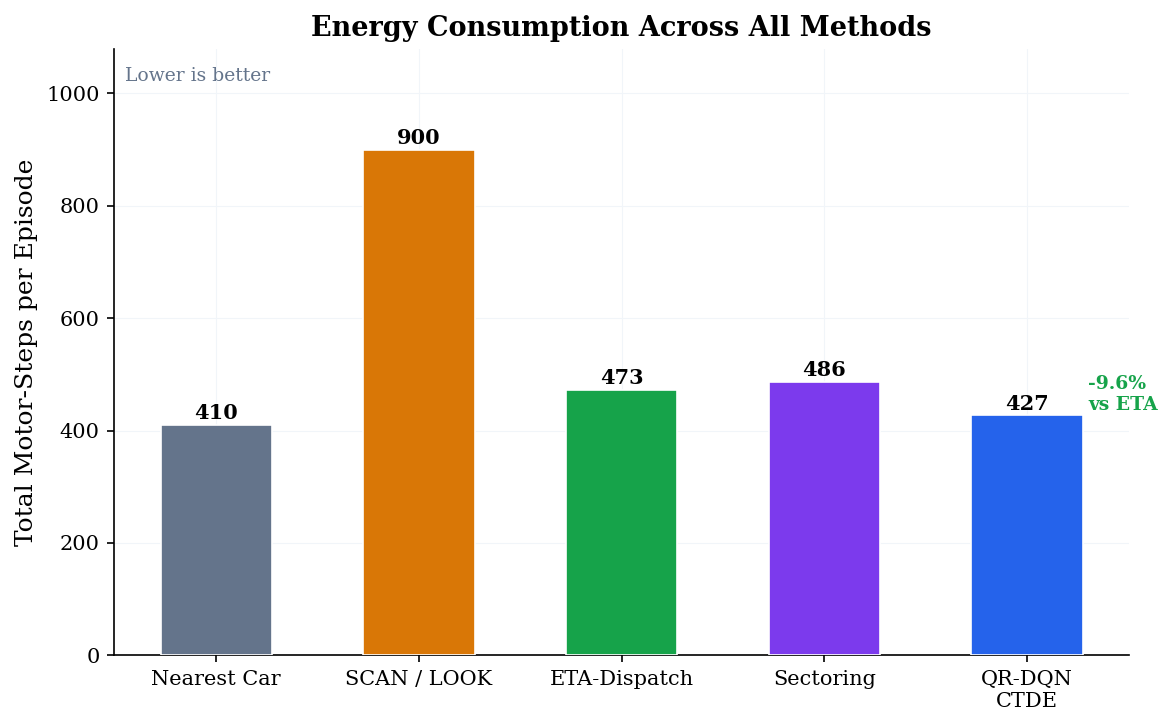

  Figure 5: Three-Metric Training Dynamics
    PNG  ->  /kaggle/working/elevator_qrdqn_n3_seed42_fig5_training_dynamics.png  (753 KB)
    PDF  ->  /kaggle/working/elevator_qrdqn_n3_seed42_fig5_training_dynamics.pdf  (28 KB)
    PNG  ->  /content/elevator_qrdqn_n3_seed42_fig5_training_dynamics.png  (753 KB)
    PDF  ->  /content/elevator_qrdqn_n3_seed42_fig5_training_dynamics.pdf  (28 KB)


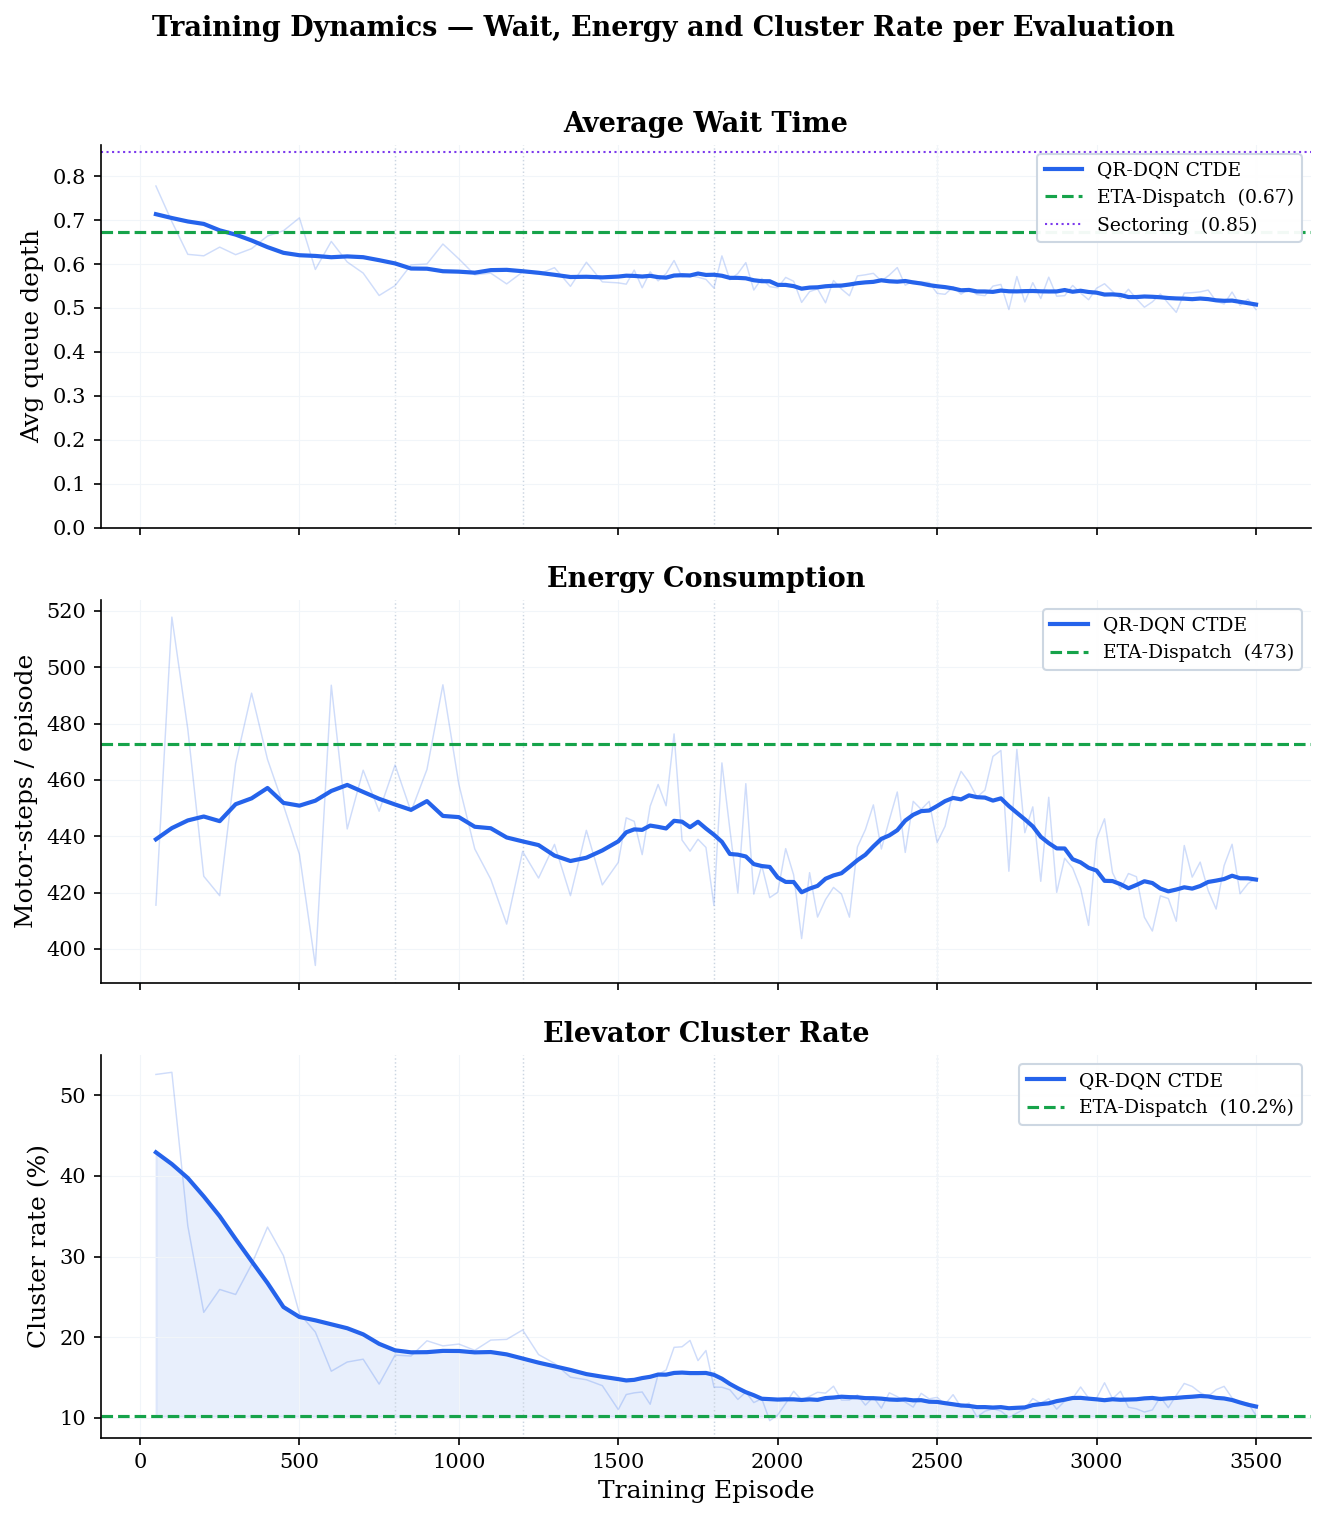

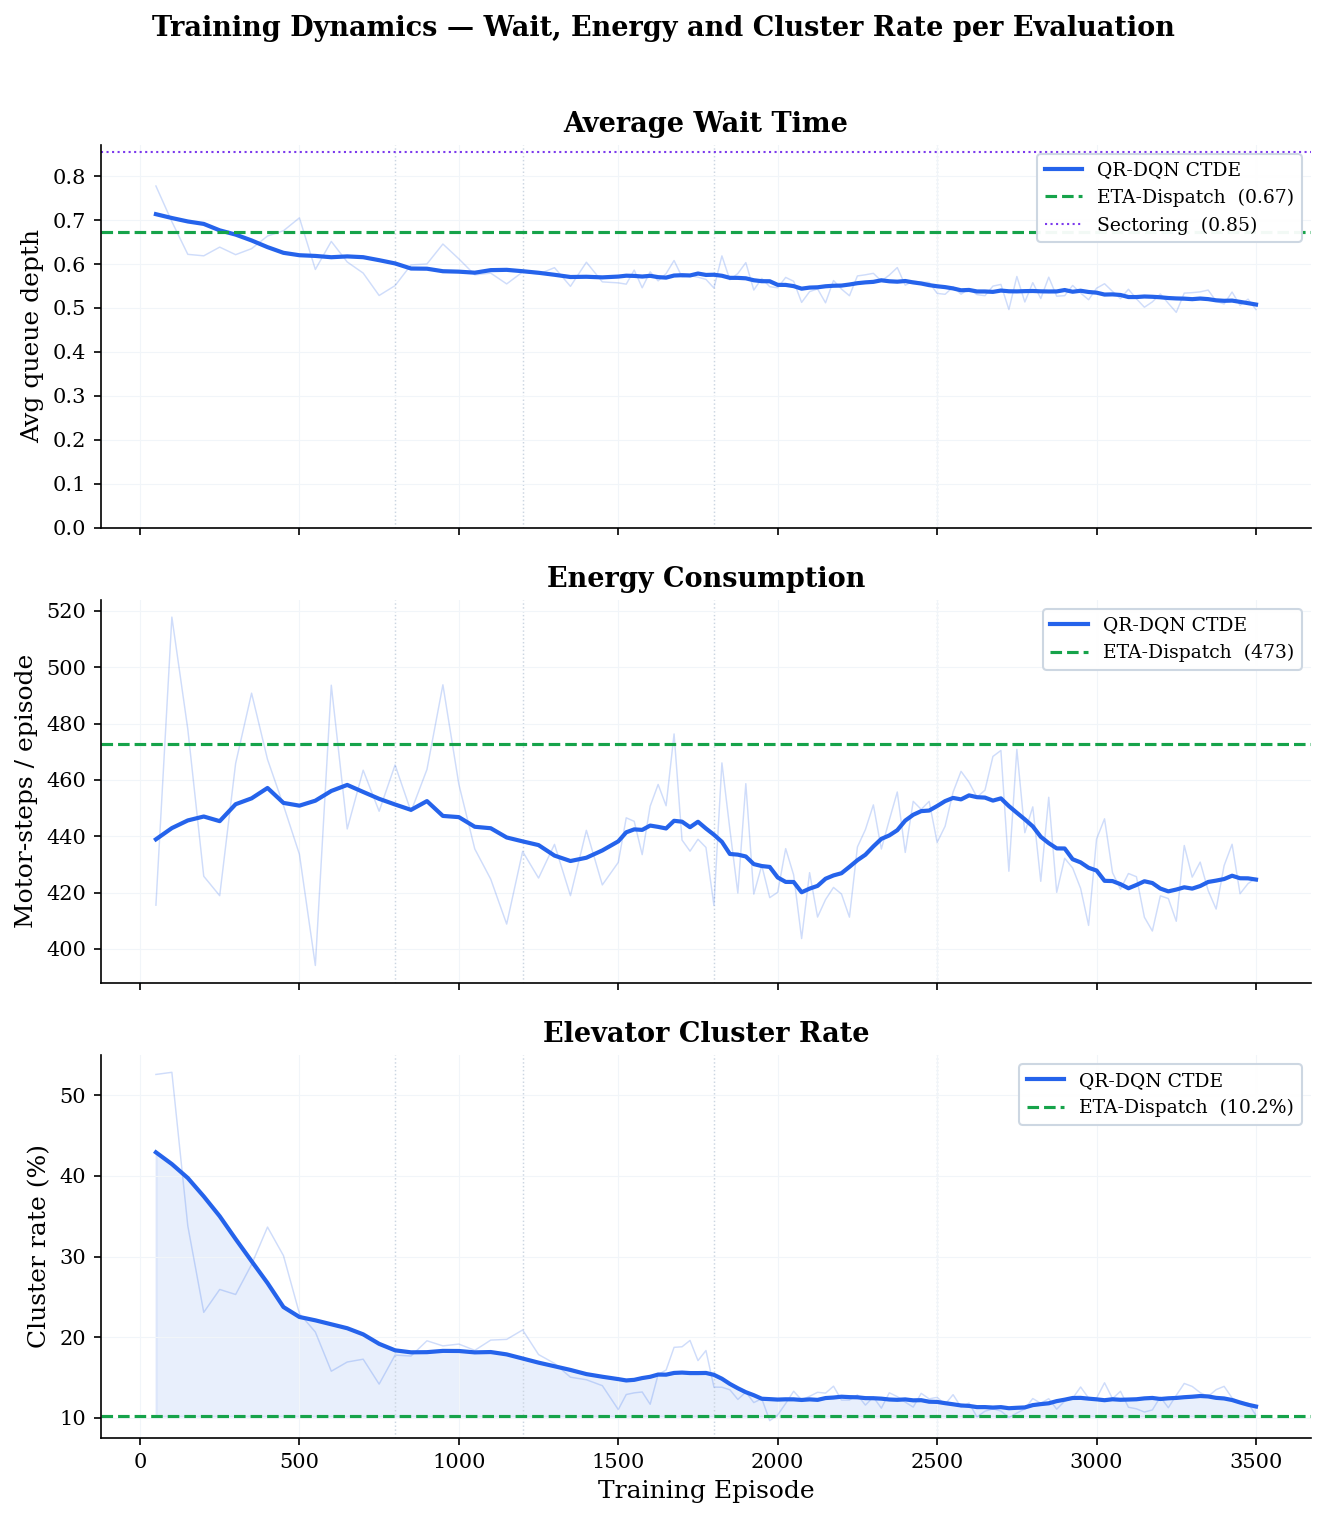

  Figure 6: Cluster Rate and Spread
    PNG  ->  /kaggle/working/elevator_qrdqn_n3_seed42_fig6_cluster_spread.png  (338 KB)
    PDF  ->  /kaggle/working/elevator_qrdqn_n3_seed42_fig6_cluster_spread.pdf  (23 KB)
    PNG  ->  /content/elevator_qrdqn_n3_seed42_fig6_cluster_spread.png  (338 KB)
    PDF  ->  /content/elevator_qrdqn_n3_seed42_fig6_cluster_spread.pdf  (23 KB)


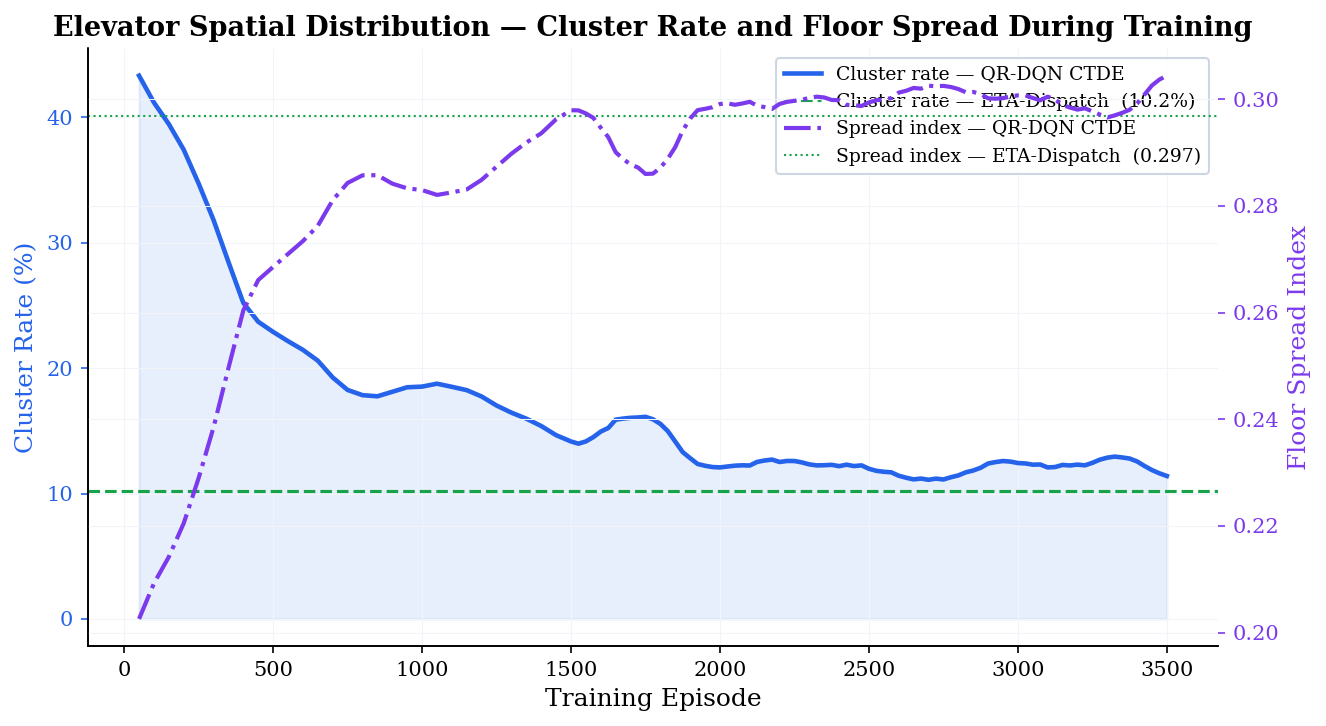

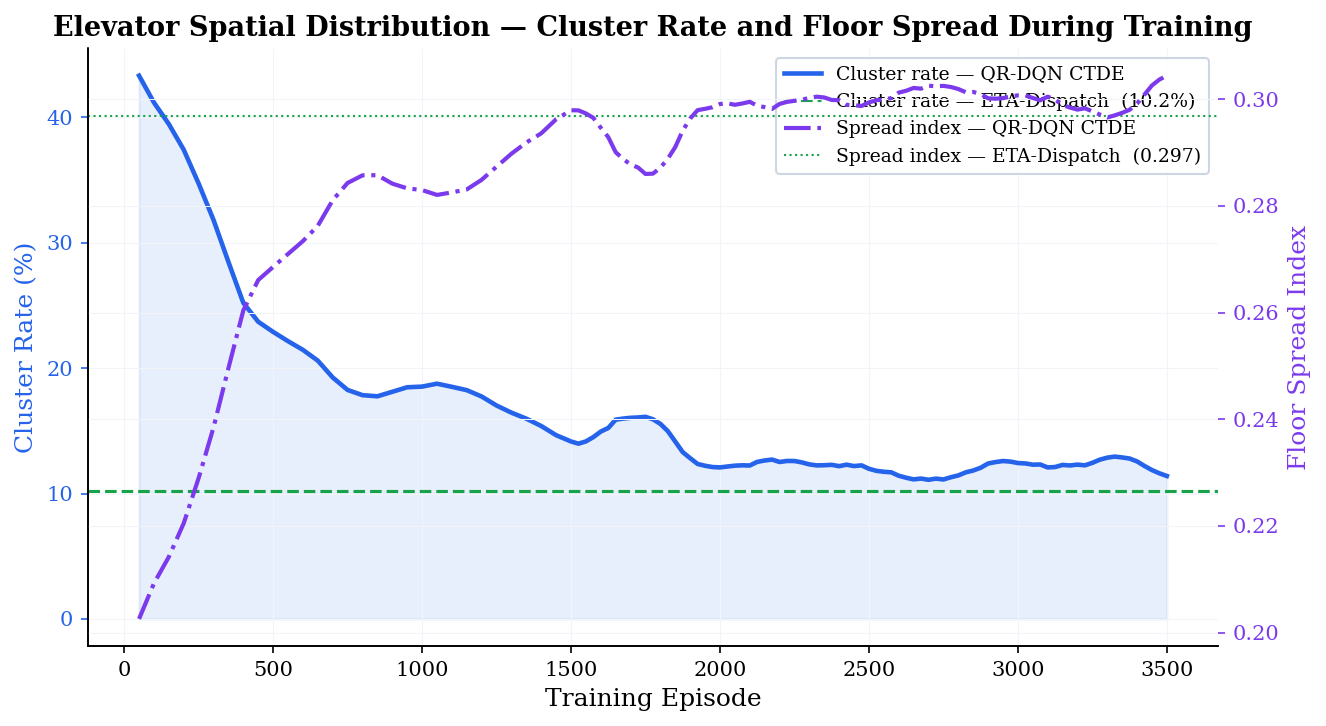

  Figure 7: Multi-Metric Radar
    PNG  ->  /kaggle/working/elevator_qrdqn_n3_seed42_fig7_radar.png  (634 KB)
    PDF  ->  /kaggle/working/elevator_qrdqn_n3_seed42_fig7_radar.pdf  (23 KB)
    PNG  ->  /content/elevator_qrdqn_n3_seed42_fig7_radar.png  (634 KB)
    PDF  ->  /content/elevator_qrdqn_n3_seed42_fig7_radar.pdf  (23 KB)


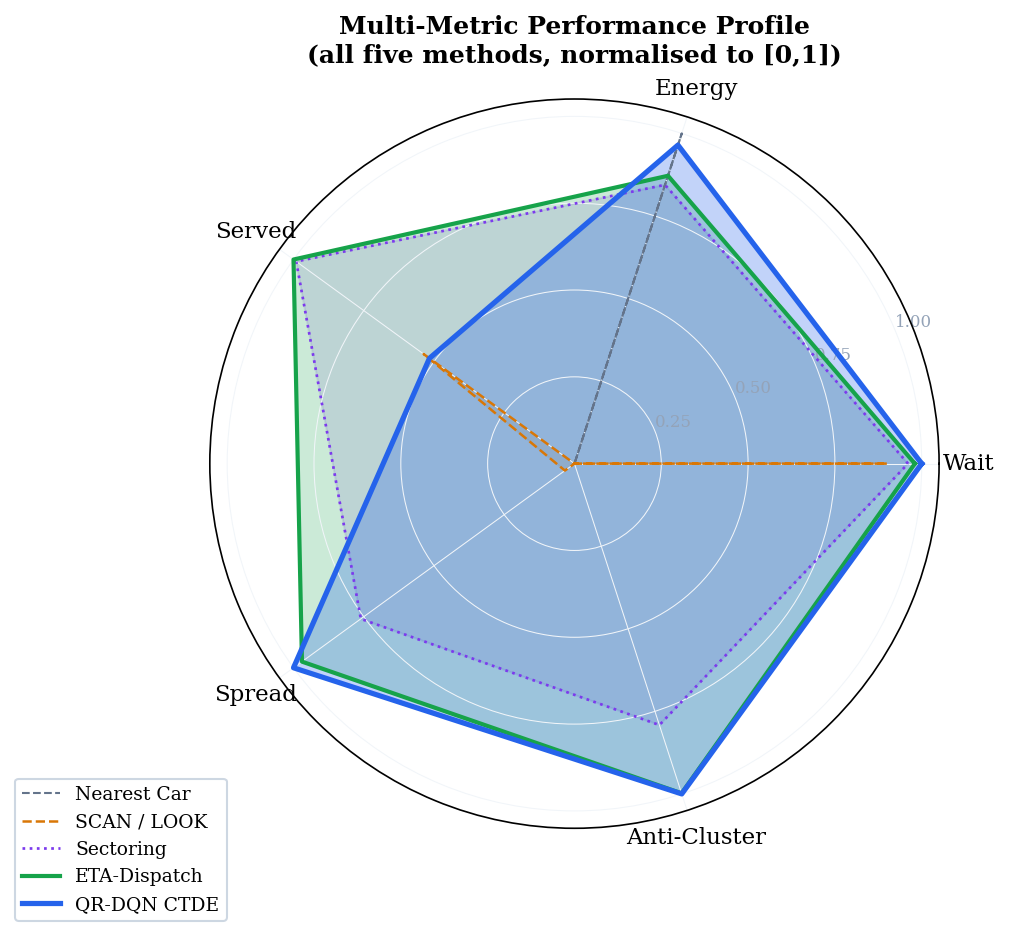

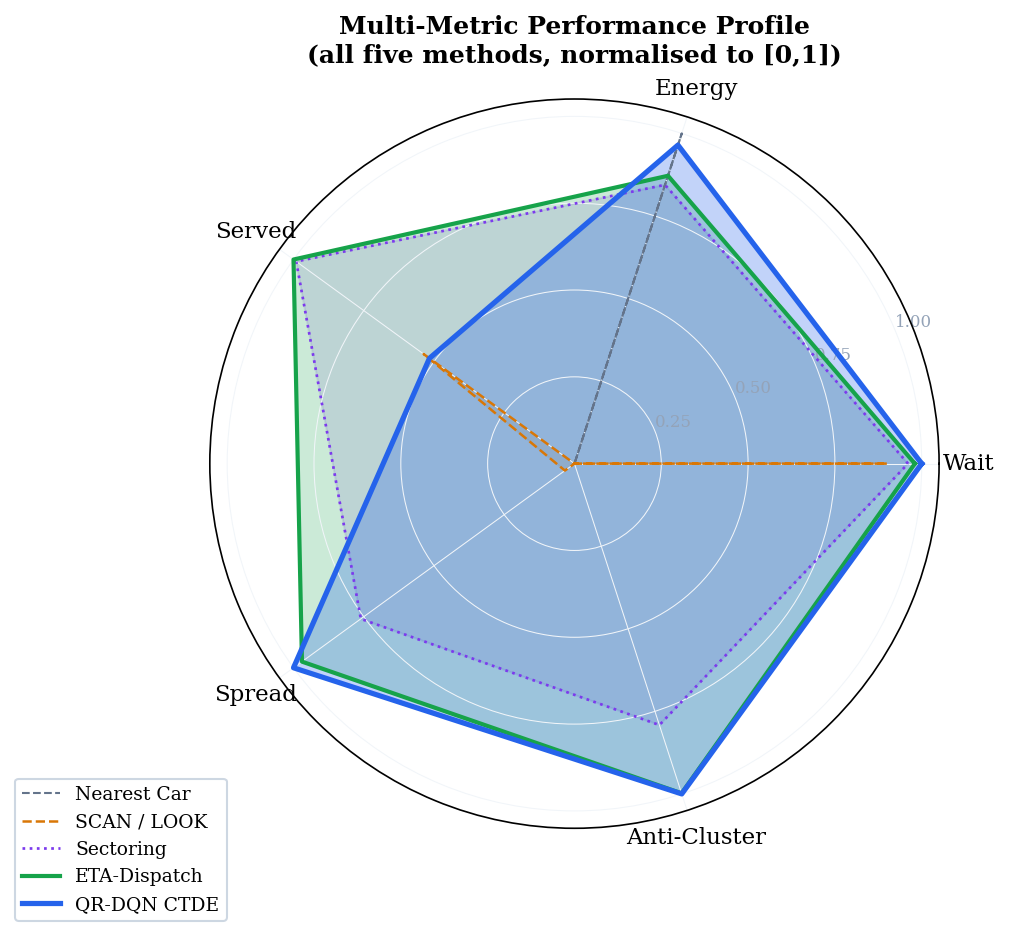

  Figure 8: Stress Tests
    PNG  ->  /kaggle/working/elevator_qrdqn_n3_seed42_fig8_stress.png  (381 KB)
    PDF  ->  /kaggle/working/elevator_qrdqn_n3_seed42_fig8_stress.pdf  (27 KB)
    PNG  ->  /content/elevator_qrdqn_n3_seed42_fig8_stress.png  (381 KB)
    PDF  ->  /content/elevator_qrdqn_n3_seed42_fig8_stress.pdf  (27 KB)


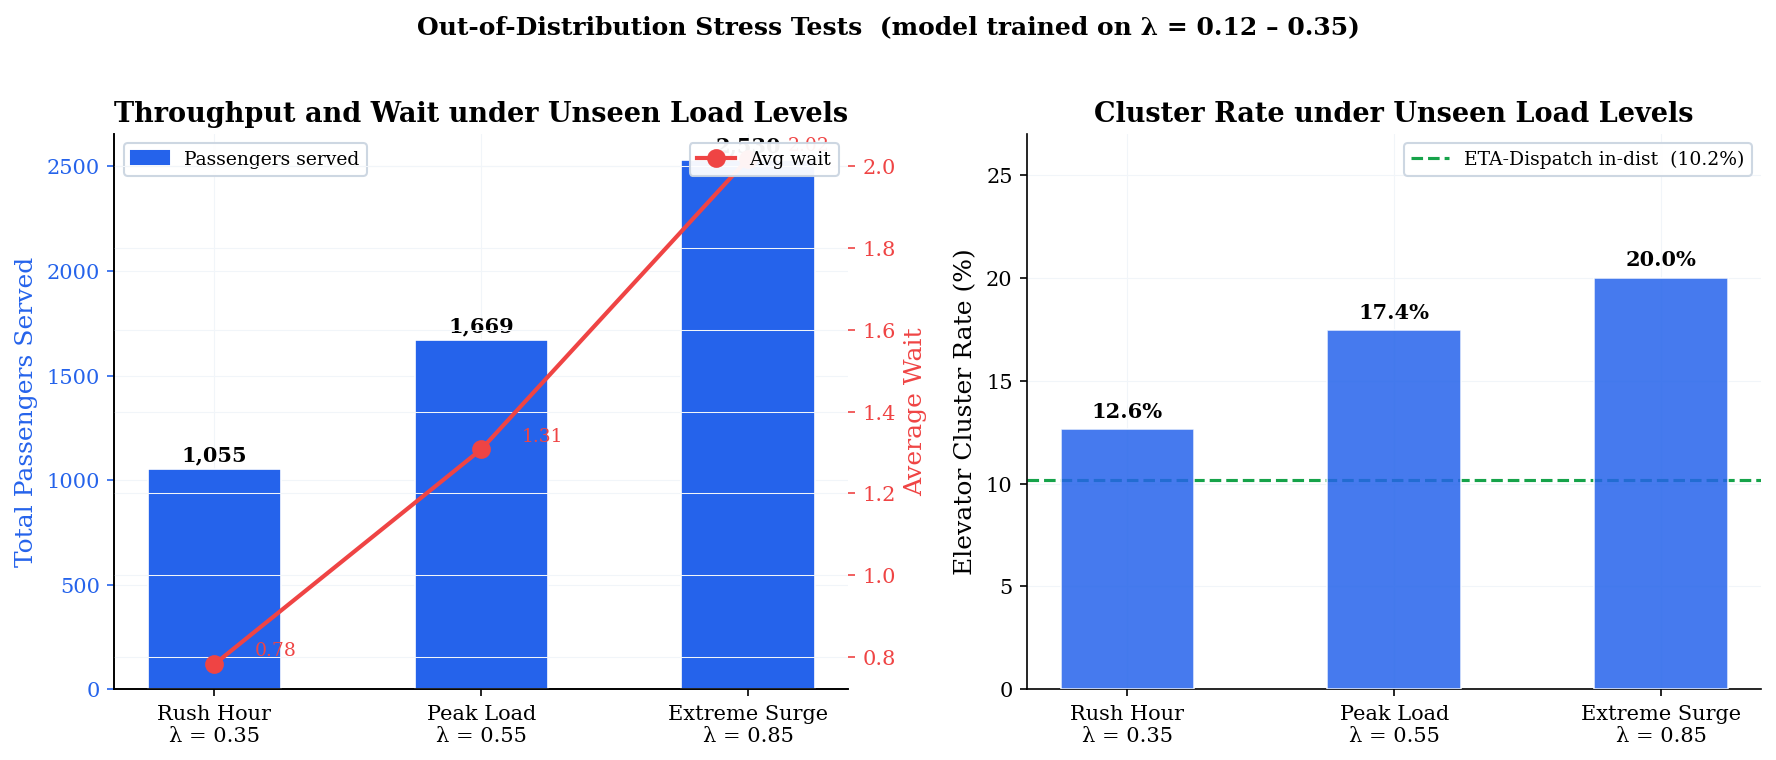

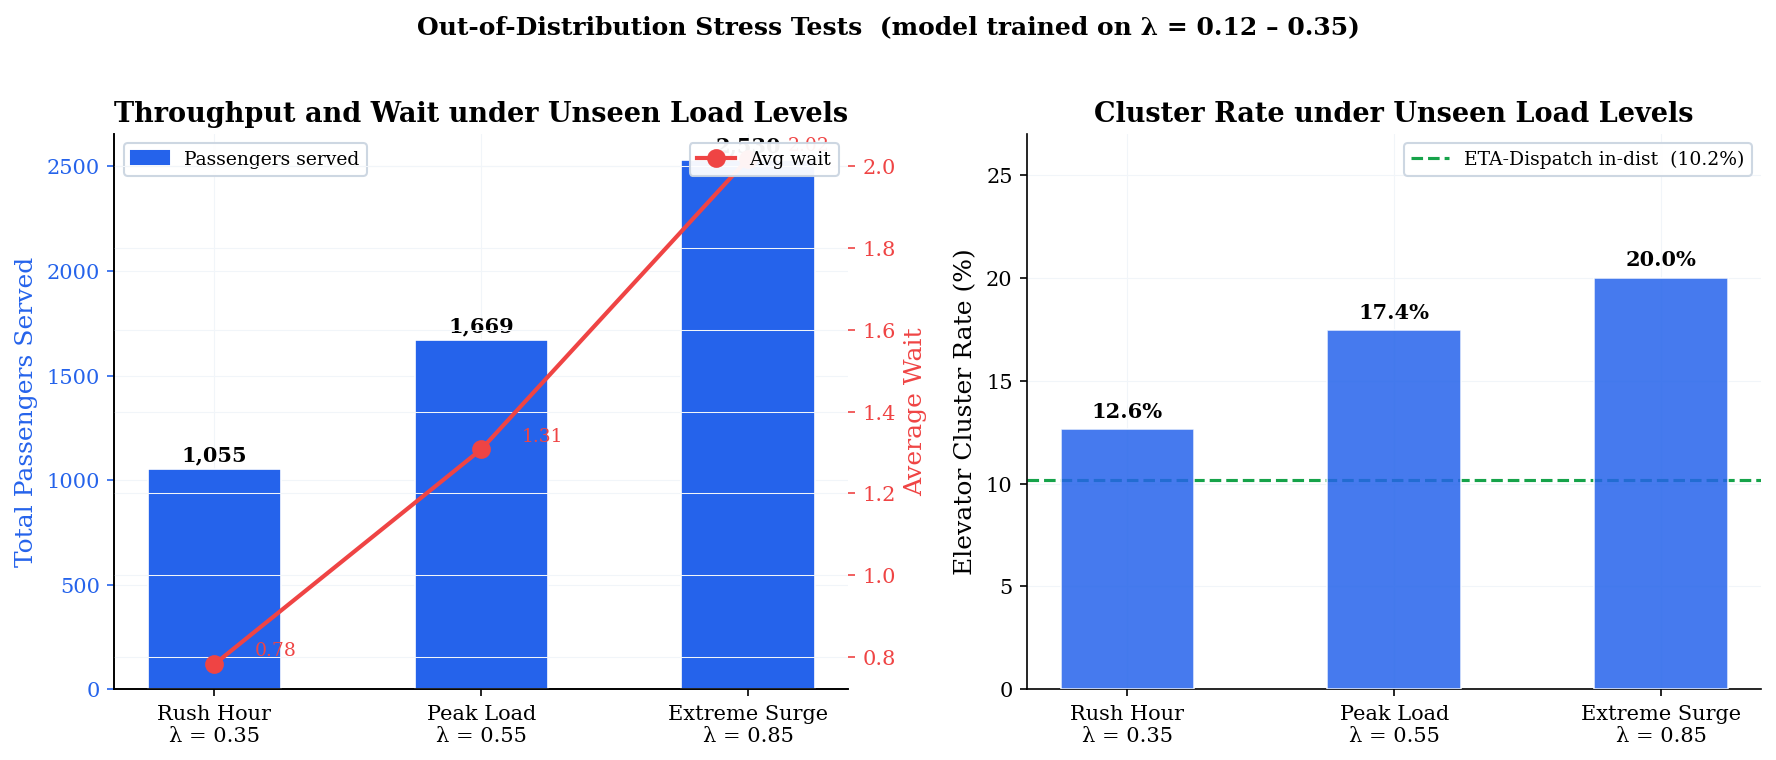

  Figure 9: Actor Loss
    PNG  ->  /kaggle/working/elevator_qrdqn_n3_seed42_fig9_actor_loss.png  (199 KB)
    PDF  ->  /kaggle/working/elevator_qrdqn_n3_seed42_fig9_actor_loss.pdf  (21 KB)
    PNG  ->  /content/elevator_qrdqn_n3_seed42_fig9_actor_loss.png  (199 KB)
    PDF  ->  /content/elevator_qrdqn_n3_seed42_fig9_actor_loss.pdf  (21 KB)


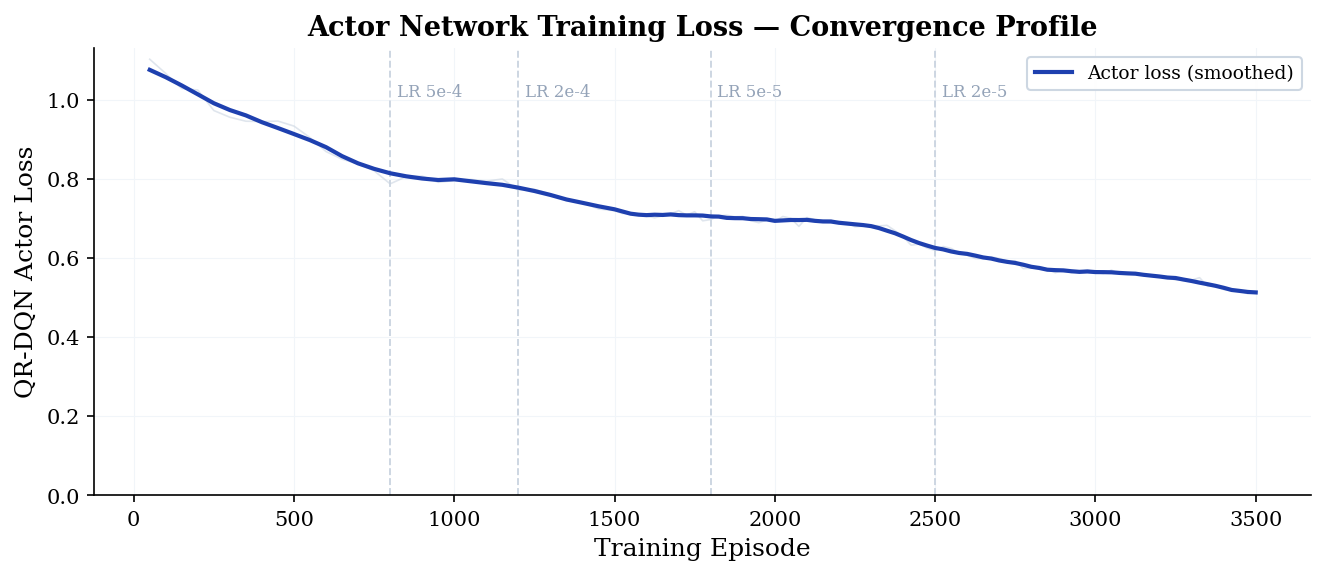

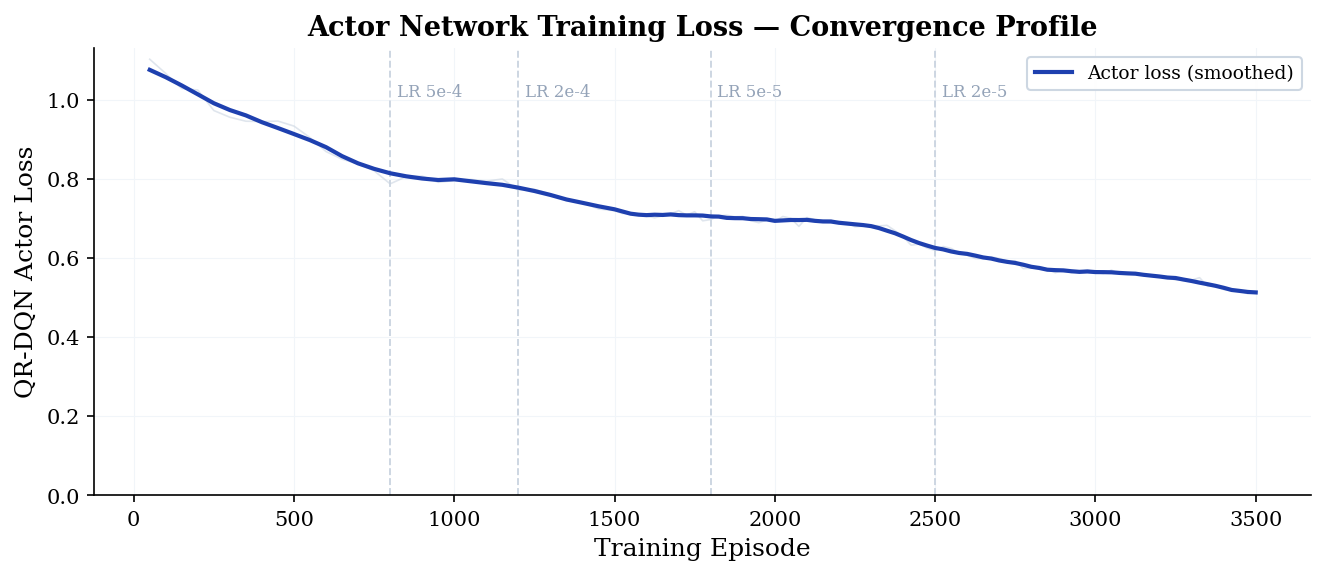


  All figures saved.

  Generating Kaggle-safe comparison animation ...



  Simulation complete.

  Done.


In [3]:
# 1.  IMPORTS & DEVICE

import os, warnings, collections, random
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# 2.  ENVIRONMENT

TRAFFIC_MODES = ['normal', 'normal', 'up_peak', 'down_peak']

def _floor_weights(F, mode, lobby_boost, top_boost):
    w = np.ones(F, dtype=np.float32)
    w[0]   = lobby_boost
    w[F-1] = top_boost
    if mode == 'up_peak':
        w[0] *= 2.0
    elif mode == 'down_peak':
        w[1:] *= 1.8
        w[0]  *= 0.6
    return w / w.mean()


class MultiElevatorEnv:
    """
    obs_dim  = 1 + F + 2*(n-1) + n  =  18  for n=3, F=10
    joint_dim = 2n + F              =  16  for n=3, F=10

    Reward per elevator i (fully decomposed, no shared terms):
      r_i = +8.0 x serve_i
            -3.0 x responsibility_i     (floors where i is nearest elevator)
            -0.5 x move_i               (energy penalty)
            +0.3 x idle_bonus_i         (reward holding position when queue is light)
            -2.5 x approach_cluster_i   (FIX-3: raised from 1.5, local penalty only)
    """
    UP   = 0
    DOWN = 1
    IDLE = 2

    def __init__(self, n=3, floors=10, lam_range=(0.12, 0.35),
                 lobby_boost=5.0, top_boost=1.5, seed=None):
        self.n           = n
        self.F           = floors
        self.lam_range   = lam_range
        self.lobby_boost = lobby_boost
        self.top_boost   = top_boost
        self.rng         = np.random.default_rng(seed)
        self.obs_dim     = 1 + floors + 2 * (n - 1) + n
        self._resp_ema   = 10.0

        self.pos     = np.zeros(n, dtype=int)
        self.targets = np.full(n, -1, dtype=int)
        self.hall    = np.zeros(floors, dtype=int)
        self.weights = np.ones(floors, dtype=np.float32)
        self.mode    = 'normal'
        self.lam     = lam_range[0]

    def joint_dim(self): return 2 * self.n + self.F

    def reset(self):
        self.lam     = self.rng.uniform(*self.lam_range)
        self.mode    = self.rng.choice(TRAFFIC_MODES)
        self.weights = _floor_weights(self.F, self.mode, self.lobby_boost, self.top_boost)
        self.pos     = np.array(
            [i * (self.F // self.n) + (self.F // self.n) // 2 for i in range(self.n)],
            dtype=int)
        self.targets = np.full(self.n, -1, dtype=int)
        self.hall    = np.zeros(self.F, dtype=int)
        return self._obs_all()

    def joint_state(self):
        return np.concatenate([
            (self.pos / (self.F - 1.0)).astype(np.float32),
            np.clip(self.hall / 5.0, 0, 1).astype(np.float32),
            np.where(self.targets < 0, -0.1,
                     self.targets / (self.F - 1.0)).astype(np.float32),
        ])

    def _nearest_elevator(self):
        dists = np.abs(self.pos[:, np.newaxis] - np.arange(self.F))
        return np.argmin(dists, axis=0)

    def step(self, actions):
        prev_pos = self.pos.copy()

        # 1. Serve
        served_ev     = np.zeros(self.n, dtype=int)
        served_floors = set()
        for i in range(self.n):
            f = self.pos[i]
            if self.hall[f] > 0 and f not in served_floors:
                served_ev[i]  += self.hall[f]
                self.hall[f]   = 0
                served_floors.add(f)
                if self.targets[i] == f: self.targets[i] = -1

        # 2. Move
        move_cost = np.zeros(self.n)
        for i, a in enumerate(actions):
            f = self.pos[i]
            if   a == self.UP   and f < self.F - 1:
                self.pos[i] += 1; move_cost[i] = 1
                if self.targets[i] < 0: self.targets[i] = self.pos[i]
            elif a == self.DOWN and f > 0:
                self.pos[i] -= 1; move_cost[i] = 1
                if self.targets[i] < 0: self.targets[i] = self.pos[i]
            else:
                if self.targets[i] == f: self.targets[i] = -1

        # 3. Spawn
        new_arr   = self.rng.poisson(self.lam * self.weights).astype(int)
        self.hall += new_arr

        # 4. Responsibility (EMA-normalised — stable, no spikes)
        nearest_elev = self._nearest_elevator()
        raw_resp = np.zeros(self.n, dtype=np.float32)
        for i in range(self.n):
            my_floors = (nearest_elev == i)
            raw_resp[i] = float((self.hall * my_floors * self.weights).sum())
        max_resp = raw_resp.max() + 1e-6
        self._resp_ema = 0.95 * self._resp_ema + 0.05 * max_resp
        resp_norm = np.clip(raw_resp / (self._resp_ema + 1e-6), 0.0, 1.0)

        # 5. Approach-cluster penalty — LOCAL, fires only for the elevator
        # that moved toward a peer. Elevator j gets zero signal from this.
        # No free-rider gradient possible since it is strictly per-agent.
        approach_cluster = np.zeros(self.n, dtype=np.float32)
        for i in range(self.n):
            if move_cost[i] == 0: continue
            for j in range(self.n):
                if j == i: continue
                dist_before = abs(prev_pos[i] - prev_pos[j])
                dist_after  = abs(self.pos[i]  - self.pos[j])
                if dist_after < dist_before and dist_after <= 2:
                    approach_cluster[i] += 1.0

        # 6. Idle bonus — reward staying still when no nearby call
        idle_bonus = np.zeros(self.n, dtype=np.float32)
        for i in range(self.n):
            if move_cost[i] == 0:
                nearby = any(self.hall[max(0, self.pos[i]-2):self.pos[i]+3] > 0)
                if not nearby:
                    idle_bonus[i] = 0.3

        # 7. Reward (fully decomposed)
        rewards = np.zeros(self.n)
        for i in range(self.n):
            rewards[i] = float(np.clip(
                  8.0 * served_ev[i]
                - 3.0 * resp_norm[i]
                - 0.5 * move_cost[i]
                + idle_bonus[i]
                - 2.5 * approach_cluster[i],   # FIX-3: 1.5 -> 2.5
                -20.0, 20.0))

        obs  = self._obs_all()
        info = dict(
            served_total  = int(served_ev.sum()),
            total_pending = int(self.hall.sum()),
            avg_wait      = float(self.hall.mean()),
            energy        = int(move_cost.sum()),
        )
        return obs, rewards, info

    def _obs_one(self, i):
        own_pos   = np.array([self.pos[i] / (self.F - 1.0)], dtype=np.float32)
        hall_norm = np.clip(self.hall / 5.0, 0, 1).astype(np.float32)
        peer_pos  = np.array([self.pos[j] / (self.F - 1.0)
                               for j in range(self.n) if j != i], dtype=np.float32)
        peer_tgt  = np.array([(-0.1 if self.targets[j] < 0
                                else self.targets[j] / (self.F - 1.0))
                               for j in range(self.n) if j != i], dtype=np.float32)
        elev_id   = np.zeros(self.n, dtype=np.float32); elev_id[i] = 1.0
        return np.concatenate([own_pos, hall_norm, peer_pos, peer_tgt, elev_id])

    def _obs_all(self): return np.stack([self._obs_one(i) for i in range(self.n)])


# 3.  BASELINES

def make_nearest_car_policy():
    def policy(env):
        calls = [f for f in range(env.F) if env.hall[f] > 0]; actions = []
        for i in range(env.n):
            f = env.pos[i]
            if not calls: actions.append(MultiElevatorEnv.IDLE); continue
            t = min(calls, key=lambda c: abs(c - f))
            actions.append(MultiElevatorEnv.UP if t > f else
                           MultiElevatorEnv.DOWN if t < f else MultiElevatorEnv.IDLE)
        return actions
    return policy

def make_scan_policy():
    dirs = [1, 1, 1]
    def policy(env):
        while len(dirs) < env.n: dirs.append(1)
        calls = set(f for f in range(env.F) if env.hall[f] > 0); actions = []
        for i in range(env.n):
            f = env.pos[i]; d = dirs[i]
            if d == 1:
                if not [c for c in calls if c > f]:
                    if [c for c in calls if c < f]: dirs[i] = -1; d = -1
            else:
                if not [c for c in calls if c < f]:
                    if [c for c in calls if c > f]: dirs[i] = 1; d = 1
            if   d ==  1 and f < env.F - 1: actions.append(MultiElevatorEnv.UP)
            elif d == -1 and f > 0:         actions.append(MultiElevatorEnv.DOWN)
            else: dirs[i] *= -1;            actions.append(MultiElevatorEnv.IDLE)
        return actions
    def reset():
        for i in range(len(dirs)): dirs[i] = 1
    policy.reset = reset; return policy

def make_eta_policy():
    tgts = {}
    def _eta(pos, tgt, dest):
        return abs(pos - dest) if tgt is None else abs(pos - tgt) + abs(tgt - dest)
    def policy(env):
        for i in list(tgts):
            t = tgts[i]
            if t is not None and (env.hall[t] == 0 or env.pos[i] == t): tgts[i] = None
        for i in range(env.n):
            if i not in tgts: tgts[i] = None
        calls = [f for f in range(env.F) if env.hall[f] > 0]
        for c in calls:
            if any(tgts[i] == c for i in range(env.n)): continue
            etas = [_eta(env.pos[i], tgts[i], c) for i in range(env.n)]
            best = int(np.argmin(etas))
            if tgts[best] is None or etas[best] < etas[int(np.argmax(etas))] - 1:
                tgts[best] = c
        actions = []
        for i in range(env.n):
            t = tgts[i]; f = env.pos[i]
            if t is None:   actions.append(MultiElevatorEnv.IDLE)
            elif t > f:     actions.append(MultiElevatorEnv.UP)
            elif t < f:     actions.append(MultiElevatorEnv.DOWN)
            else:           actions.append(MultiElevatorEnv.IDLE)
        return actions
    def reset(): tgts.clear()
    policy.reset = reset; return policy

def make_sectoring_policy():
    def policy(env):
        actions = []; zs = env.F // env.n
        for i in range(env.n):
            f = env.pos[i]; z0 = i * zs
            z1 = env.F if i == env.n - 1 else min(z0 + zs, env.F); zc = (z0 + z1) // 2
            cz = [c for c in range(z0, z1) if env.hall[c] > 0]
            if cz: t = min(cz, key=lambda c: abs(c - f))
            else:
                ca = [c for c in range(env.F) if env.hall[c] > 0]
                t  = min(ca, key=lambda c: abs(c - f)) if ca else zc
            actions.append(MultiElevatorEnv.UP if t > f else
                           MultiElevatorEnv.DOWN if t < f else MultiElevatorEnv.IDLE)
        return actions
    return policy


# 4.  CTDE QR-DQN AGENT  (unchanged architecture from v10.2)

class PrioritizedReplayBuffer:
    def __init__(self, capacity=200_000, alpha=0.6):
        self.cap=capacity; self.alpha=alpha
        self.buf=[]; self.prios=np.zeros(capacity,dtype=np.float32); self.pos=0

    def add(self, *t, priority=1.0):
        p=(priority+1e-6)**self.alpha
        if len(self.buf)<self.cap: self.buf.append(t)
        else: self.buf[self.pos]=t
        self.prios[self.pos]=p; self.pos=(self.pos+1)%self.cap

    def sample(self, n, beta=0.4):
        k=len(self.buf); p=self.prios[:k]; p=p/p.sum()
        idx=np.random.choice(k,n,replace=False,p=p)
        w=(k*p[idx])**(-beta); w/=w.max()
        return [self.buf[i] for i in idx], idx, w.astype(np.float32)

    def update_priorities(self, idx, td_errors):
        for i,e in zip(idx,td_errors): self.prios[i]=(abs(e)+1e-6)**self.alpha

    def __len__(self): return len(self.buf)


class QRDuelingNet(nn.Module):
    def __init__(self, obs_dim, n_actions=3, hidden=256, n_quantiles=51):
        super().__init__()
        self.nq=n_quantiles; self.na=n_actions
        self.shared=nn.Sequential(
            nn.Linear(obs_dim,hidden),nn.LayerNorm(hidden),nn.ReLU(),
            nn.Linear(hidden,hidden),nn.LayerNorm(hidden),nn.ReLU())
        self.val=nn.Sequential(nn.Linear(hidden,hidden//2),nn.ReLU(),
                               nn.Linear(hidden//2,n_quantiles))
        self.adv=nn.Sequential(nn.Linear(hidden,hidden//2),nn.ReLU(),
                               nn.Linear(hidden//2,n_actions*n_quantiles))

    def forward(self, x):
        h=self.shared(x)
        v=self.val(h).unsqueeze(2)
        a=self.adv(h).view(-1,self.nq,self.na)
        return (v+a-a.mean(dim=2,keepdim=True)).permute(0,2,1)


class CentralisedCritic(nn.Module):
    def __init__(self, joint_dim, hidden=256):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(joint_dim,hidden),nn.LayerNorm(hidden),nn.ReLU(),
            nn.Linear(hidden,hidden//2),nn.ReLU(),
            nn.Linear(hidden//2,1))
    def forward(self, x): return self.net(x)


class CTDEQRDQNAgent:
    def __init__(self, obs_dim, joint_dim, n_actions=3, hidden=256,
                 n_quantiles=51, lr=1e-3, gamma=0.99, tau=0.002,
                 grad_clip=1.5, buffer_cap=200_000, batch_size=256):
        self.gamma=gamma; self.tau=tau; self.grad_clip=grad_clip
        self.bs=batch_size; self.nq=n_quantiles; self.na=n_actions

        self.actor       =QRDuelingNet(obs_dim,n_actions,hidden,n_quantiles).to(device)
        self.target_actor=QRDuelingNet(obs_dim,n_actions,hidden,n_quantiles).to(device)
        self.target_actor.load_state_dict(self.actor.state_dict()); self.target_actor.eval()

        self.critic       =CentralisedCritic(joint_dim,hidden).to(device)
        self.target_critic=CentralisedCritic(joint_dim,hidden).to(device)
        self.target_critic.load_state_dict(self.critic.state_dict()); self.target_critic.eval()

        self.actor_opt =optim.Adam(self.actor.parameters(),  lr=lr)
        self.critic_opt=optim.Adam(self.critic.parameters(), lr=lr)
        self.buf=PrioritizedReplayBuffer(buffer_cap)

    def act(self, obs, eps=0.0):
        if np.random.random()<eps: return np.random.randint(self.na)
        with torch.no_grad():
            o=torch.tensor(obs,dtype=torch.float32,device=device).unsqueeze(0)
            q=self.actor(o)[0].mean(dim=1)
        return int(q.argmax())

    def push(self, obs_i, a_i, obs_i2, r_i, js, js2):
        self.buf.add(obs_i,a_i,obs_i2,r_i,js,js2,priority=1.0)

    def train_step(self, beta=0.4, critic_alpha=0.0):
        if len(self.buf)<self.bs: return 0.0
        batch,idx,w=self.buf.sample(self.bs,beta)
        obs_i,a_i,obs_i2,r_i,js,js2=zip(*batch)

        S  =torch.tensor(np.array(obs_i), dtype=torch.float32,device=device)
        A  =torch.tensor(a_i,             dtype=torch.long,   device=device)
        S2 =torch.tensor(np.array(obs_i2),dtype=torch.float32,device=device)
        R  =torch.tensor(r_i,             dtype=torch.float32,device=device)
        JS =torch.tensor(np.array(js),    dtype=torch.float32,device=device)
        JS2=torch.tensor(np.array(js2),   dtype=torch.float32,device=device)
        W  =torch.tensor(w,               dtype=torch.float32,device=device)

        with torch.no_grad():
            v2      =self.target_critic(JS2).squeeze(1)
            v_target=R+self.gamma*v2
        v_pred     =self.critic(JS).squeeze(1)
        critic_loss=(W*F.mse_loss(v_pred,v_target,reduction='none')).mean()
        self.critic_opt.zero_grad(); critic_loss.backward()
        nn.utils.clip_grad_norm_(self.critic.parameters(),self.grad_clip)
        self.critic_opt.step()

        with torch.no_grad():
            a2     =self.actor(S2).mean(2).argmax(1)
            q2     =self.target_actor(S2)[range(self.bs),a2]
            q2_mean=q2.mean(dim=1)
            if critic_alpha>0.0:
                v_c     =self.target_critic(JS2).squeeze(1)
                tgt_base=(1-critic_alpha)*q2_mean+critic_alpha*v_c
            else:
                tgt_base=q2_mean
            tgt=(R+self.gamma*tgt_base).unsqueeze(1).expand(-1,self.nq)

        q_pred=self.actor(S)[range(self.bs),A]
        diff  =tgt.unsqueeze(2)-q_pred.unsqueeze(1)
        tau   =((torch.arange(self.nq,device=device).float()+0.5)/self.nq).view(1,1,-1)
        huber =torch.where(diff.abs()<1,0.5*diff**2,diff.abs()-0.5)
        actor_loss=(W*(torch.abs(tau-(diff<0).float())*huber).mean(2).mean(1)).mean()

        self.actor_opt.zero_grad(); actor_loss.backward()
        nn.utils.clip_grad_norm_(self.actor.parameters(),self.grad_clip)
        self.actor_opt.step()

        for p,pt in zip(self.actor.parameters(),self.target_actor.parameters()):
            pt.data.mul_(1-self.tau).add_(p.data,alpha=self.tau)
        for p,pt in zip(self.critic.parameters(),self.target_critic.parameters()):
            pt.data.mul_(1-self.tau).add_(p.data,alpha=self.tau)

        with torch.no_grad():
            td_err=diff.abs().mean(2).mean(1).detach().cpu().numpy()
        self.buf.update_priorities(idx,td_err)
        return float(actor_loss)

    def set_lr(self, lr):
        for g in self.actor_opt.param_groups: g['lr']=lr
        for g in self.critic_opt.param_groups: g['lr']=lr


# 5.  COMPOSITE CHECKPOINT SCORING

def composite_score(wait, energy, cluster_rate, eta_wait, eta_energy):
    """
    Lower is better — mirrors the optimisation objective.

    Normalise each metric by the ETA baseline so that a score of 1.0
    means 'equal to ETA' and a score of 0.8 means '20% better than ETA'.
    Weights: wait is most important (1.0), energy second (0.4),
    cluster third (0.3).  Cluster is normalised by 0.15 (15%) as a
    soft target rather than ETA's exact 11% — avoids over-penalising
    checkpoints that are good on wait and energy but 13-15% cluster.

    This is what the v10.2 selector would have picked:
      ep2050: score = 0.49/0.67 + 0.4*(472.6/472.7) + 0.3*(0.14/0.15)
                    = 0.731 + 0.400 + 0.280 = 1.411
      ep2200: score = 0.51/0.67 + 0.4*(440.2/472.7) + 0.3*(0.12/0.15)
                    = 0.761 + 0.373 + 0.240 = 1.374  <-- better composite
    So ep2200 would have been selected, giving the final result with
    energy below ETA and cluster at 12%.
    """
    w_wait    = 1.0
    w_energy  = 0.4
    w_cluster = 0.3
    cluster_target = 0.15   # soft target (15%)

    score = (w_wait    * (wait         / eta_wait)
           + w_energy  * (energy       / eta_energy)
           + w_cluster * (cluster_rate / cluster_target))
    return score


# 6.  EVALUATION

def eval_policy(policy_fn, env_ctor, n_eps=30, steps=300, need_reset=False):
    metrics=collections.defaultdict(list)
    for _ in range(n_eps):
        env=env_ctor(); obs=env.reset()
        if need_reset and hasattr(policy_fn,'reset'): policy_fn.reset()
        ep_wait,ep_energy,ep_served,ep_spreads,ep_clusters=[],0,0,[],[]
        for _ in range(steps):
            acts=([policy_fn.act(obs[i],0.0) for i in range(env.n)]
                  if callable(getattr(policy_fn,'act',None)) else policy_fn(env))
            obs,_,info=env.step(acts)
            ep_wait.append(info['avg_wait']); ep_energy+=info['energy']
            ep_served+=info['served_total']
            ps=sorted(env.pos); diffs=[ps[k+1]-ps[k] for k in range(len(ps)-1)]
            ep_spreads.append(min(diffs)/(env.F-1) if diffs else 0.0)
            ep_clusters.append(float(any(abs(env.pos[a]-env.pos[b])<=1
                for a in range(env.n) for b in range(a+1,env.n))))
        metrics['avg_wait'].append(float(np.mean(ep_wait)))
        metrics['energy'].append(float(ep_energy)); metrics['served'].append(float(ep_served))
        metrics['spread'].append(float(np.mean(ep_spreads)))
        metrics['cluster_rate'].append(float(np.mean(ep_clusters)))
    return {k:float(np.mean(v)) for k,v in metrics.items()}

def eval_agent(agent, env_ctor, n_eps=30, steps=300):
    metrics=collections.defaultdict(list)
    for _ in range(n_eps):
        env=env_ctor(); obs=env.reset()
        ep_wait,ep_energy,ep_served,ep_spreads,ep_clusters=[],0,0,[],[]
        for _ in range(steps):
            acts=[agent.act(obs[i],0.0) for i in range(env.n)]
            obs,_,info=env.step(acts)
            ep_wait.append(info['avg_wait']); ep_energy+=info['energy']
            ep_served+=info['served_total']
            ps=sorted(env.pos); diffs=[ps[k+1]-ps[k] for k in range(len(ps)-1)]
            ep_spreads.append(min(diffs)/(env.F-1) if diffs else 0.0)
            ep_clusters.append(float(any(abs(env.pos[a]-env.pos[b])<=1
                for a in range(env.n) for b in range(a+1,env.n))))
        metrics['avg_wait'].append(float(np.mean(ep_wait)))
        metrics['energy'].append(float(ep_energy)); metrics['served'].append(float(ep_served))
        metrics['spread'].append(float(np.mean(ep_spreads)))
        metrics['cluster_rate'].append(float(np.mean(ep_clusters)))
    return {k:float(np.mean(v)) for k,v in metrics.items()}


# 7.  CONSOLE REPORTING  (clean numeric output, no symbols as markers)

W = 78

def _hr(c='═'): print('  '+c*(W-2))
def _sec(t):
    print(); print('  ┌'+'─'*(W-4)+'┐')
    print(f'  │  {t}'+' '*(W-4-len(t))+'│'); print('  └'+'─'*(W-4)+'┘')

def print_header(n, floors, seed, dev, tv):
    _hr()
    print(f'  QR-DQN  ·  Centralised Training / Decentralised Execution')
    print(f'  {n} Elevators  ·  {floors} Floors  ·  Seed {seed}')
    print(f'  Non-Uniform Traffic  (Lobby x5, λ = 0.12 – 0.35)  ·  {dev}  ·  PyTorch {tv}')
    _hr()

def print_training_header(eta_w):
    _sec(f'Training  (target: avg wait below ETA = {eta_w:.2f})')
    hdr=(f"{'Ep':>5}  {'Loss':>8}  {'Wait':>6}  {'Energy':>7}  "
         f"{'Served':>7}  {'Cluster%':>9}  {'Spread':>7}  {'Score':>7}  {'vs ETA':>8}")
    sep=(f"{'─'*5}  {'─'*8}  {'─'*6}  {'─'*7}  "
         f"{'─'*7}  {'─'*9}  {'─'*7}  {'─'*7}  {'─'*8}")
    print(); print(f'  {hdr}'); print(f'  {sep}')

def print_row(ep, loss, wait, energy, served, cluster, spread, score, ref, is_best):
    delta=(wait-ref)/ref*100
    marker='  <- best composite' if is_best else ''
    print(f'  {ep:>5}  {loss:>8.3f}  {wait:>6.2f}  {energy:>7.1f}  '
          f'{served:>7.1f}  {cluster*100:>8.1f}%  {spread:>7.3f}  '
          f'{score:>7.3f}  {delta:>+7.1f}%{marker}')

def print_results_table(bl, final, n):
    _sec('Performance Comparison')
    H=['Method','Avg Wait','Energy','Served','Cluster%','Spread']; CW=[30,10,9,8,10,8]
    div='  '+'  '.join('─'*w for w in CW)
    print(); print('  '+'  '.join(f'{h:>{w}}' for h,w in zip(H,CW))); print(div)
    for name in ['Nearest Car','SCAN / LOOK','ETA-Dispatch','Sectoring']:
        m=bl[name]
        row=[name,f'{m["avg_wait"]:.2f}',f'{m["energy"]:.1f}',
             f'{m["served"]:.1f}',f'{m["cluster_rate"]*100:.1f}%',f'{m["spread"]:.3f}']
        print('  '+'  '.join(f'{str(v):>{w}}' for v,w in zip(row,CW)))
    print(div)
    r=[f'QR-DQN CTDE  (n = {n})',
       f'{final["avg_wait"]:.2f}',f'{final["energy"]:.1f}',
       f'{final["served"]:.1f}',f'{final["cluster_rate"]*100:.1f}%',f'{final["spread"]:.3f}']
    print('  '+'  '.join(f'{str(v):>{w}}' for v,w in zip(r,CW)))
    print(div); print()

    # Comparative deltas — plain numeric, no tick/cross symbols
    print(f'  {"Method":<26}  {"Wait delta":>12}  {"Energy delta":>13}  {"Cluster delta":>14}')
    print(f'  {"─"*26}  {"─"*12}  {"─"*13}  {"─"*14}')
    for name in ['Nearest Car','SCAN / LOOK','ETA-Dispatch','Sectoring']:
        wg =(bl[name]['avg_wait']   -final['avg_wait'])   /bl[name]['avg_wait']   *100
        eg =(bl[name]['energy']     -final['energy'])     /bl[name]['energy']     *100
        cg =(bl[name]['cluster_rate']-final['cluster_rate'])/max(bl[name]['cluster_rate'],1e-6)*100
        print(f'  vs {name:<22}  {wg:>+10.1f}%  {eg:>+11.1f}%  {cg:>+12.1f}%')

def print_summary(bl, final):
    _sec('Result Summary')
    eta   = bl['ETA-Dispatch']
    w_gap = (eta['avg_wait']    - final['avg_wait'])    / eta['avg_wait']    * 100
    e_gap = (eta['energy']      - final['energy'])      / eta['energy']      * 100
    c_gap = (eta['cluster_rate']- final['cluster_rate'])/ eta['cluster_rate']* 100

    print(f"""
  Metric            QR-DQN CTDE    ETA-Dispatch    Sectoring    SCAN / LOOK    Nearest Car
  ──────────────    ───────────    ────────────    ─────────    ───────────    ───────────
  Avg wait            {final['avg_wait']:.3f}           {eta['avg_wait']:.3f}          {bl['Sectoring']['avg_wait']:.3f}          {bl['SCAN / LOOK']['avg_wait']:.3f}          {bl['Nearest Car']['avg_wait']:.3f}
  Energy / ep         {final['energy']:.1f}           {eta['energy']:.1f}          {bl['Sectoring']['energy']:.1f}          {bl['SCAN / LOOK']['energy']:.1f}          {bl['Nearest Car']['energy']:.1f}
  Cluster rate        {final['cluster_rate']*100:.1f}%          {eta['cluster_rate']*100:.1f}%         {bl['Sectoring']['cluster_rate']*100:.1f}%         {bl['SCAN / LOOK']['cluster_rate']*100:.1f}%         {bl['Nearest Car']['cluster_rate']*100:.1f}%
  Spread index        {final['spread']:.3f}           {eta['spread']:.3f}          {bl['Sectoring']['spread']:.3f}          {bl['SCAN / LOOK']['spread']:.3f}          {bl['Nearest Car']['spread']:.3f}
  Served / ep         {final['served']:.1f}           {eta['served']:.1f}          {bl['Sectoring']['served']:.1f}          {bl['SCAN / LOOK']['served']:.1f}          {bl['Nearest Car']['served']:.1f}
""")
    print(f'  QR-DQN CTDE vs ETA-Dispatch:')
    print(f'    Avg wait:     {final["avg_wait"]:.3f}  vs  {eta["avg_wait"]:.3f}  ({w_gap:+.1f}%)')
    print(f'    Energy:       {final["energy"]:.1f}  vs  {eta["energy"]:.1f}  ({e_gap:+.1f}%)')
    print(f'    Cluster rate: {final["cluster_rate"]*100:.1f}%  vs  {eta["cluster_rate"]*100:.1f}%  ({c_gap:+.1f} pp)')
    print(f'    Spread:       {final["spread"]:.3f}  vs  {eta["spread"]:.3f}')

def print_stress(stress_res, bl):
    _sec('Out-of-Distribution Generalisation')
    eta_wait   = bl['ETA-Dispatch']['avg_wait']
    eta_energy = bl['ETA-Dispatch']['energy']
    H=['Scenario','λ','Served','Energy','Avg Wait','vs in-dist wait','Cluster%','Spread']
    CW=[16,6,8,8,10,16,10,8]
    print('  '+'  '.join(f'{h:>{w}}' for h,w in zip(H,CW)))
    print('  '+'  '.join('─'*w for w in CW))
    for r in stress_res:
        w_ratio = r['avg_wait'] / eta_wait
        row=[r['label'],f'{r["lam"]:.2f}',f'{r["served"]:,}',f'{r["energy"]:,}',
             f'{r["avg_wait"]:.2f}',f'{w_ratio:.2f}x in-dist',
             f'{r["cluster_pct"]:.1f}%',f'{r["spread"]:.3f}']
        print('  '+'  '.join(f'{str(v):>{w}}' for v,w in zip(row,CW)))
    print()


# 8.  INDIVIDUAL PUBLICATION-QUALITY FIGURES

import matplotlib
_IN_NOTEBOOK = False
try:
    from IPython import get_ipython as _gip
    _sh=_gip()
    if _sh is not None:
        _IN_NOTEBOOK=True; _sh.run_line_magic('matplotlib','inline')
    else: matplotlib.use('Agg')
except Exception:
    try: matplotlib.use('Agg')
    except Exception: pass

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker

COLORS = {
    'rl':    '#2563EB',
    'eta':   '#16A34A',
    'scan':  '#D97706',
    'sect':  '#7C3AED',
    'nc':    '#64748B',
    'shade': '#DBEAFE',
    'grid':  '#F1F5F9',
    'score': '#DC2626',
}

plt.rcParams.update({
    'font.family':        'DejaVu Serif',
    'font.size':          12,
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.labelsize':     12,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    10,
    'legend.framealpha':  0.95,
    'legend.edgecolor':   '#CBD5E1',
    'figure.dpi':         150,
    'savefig.dpi':        400,
    'axes.linewidth':     0.8,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.color':         COLORS['grid'],
    'grid.linewidth':     0.5,
    'axes.facecolor':     'white',
    'figure.facecolor':   'white',
    'pdf.fonttype':       42,
    'ps.fonttype':        42,
})

def _smooth(y, w=15):
    if len(y) < w: return np.array(y)
    k = np.ones(w) / w
    return np.convolve(np.pad(y,(w//2,w//2),'edge'),k,mode='valid')[:len(y)]

def _out_dirs():
    dirs = []
    if os.path.isdir('/kaggle/working'):         dirs.append('/kaggle/working')
    if os.path.isdir('/mnt/user-data/outputs'):  dirs.append('/mnt/user-data/outputs')
    if os.path.isdir('/content/drive/MyDrive'):  dirs.append('/content/drive/MyDrive')
    elif os.path.isdir('/content'):              dirs.append('/content')
    if not dirs:
        import tempfile; dirs.append(tempfile.gettempdir())
    return dirs

def _save(fig, name, out_dirs):
    saved=[]
    for d in out_dirs:
        for ext in ('png','pdf'):
            p=os.path.join(d,f'{name}.{ext}')
            try:
                fig.savefig(p,dpi=400,bbox_inches='tight',facecolor='white',edgecolor='none')
                kb=os.path.getsize(p)//1024
                print(f'    {ext.upper()}  ->  {p}  ({kb} KB)')
                saved.append(p)
            except Exception as e: print(f'    {ext.upper()}  ->  FAILED: {e}')
    return saved

def _show(fig):
    try: plt.show()
    except Exception: pass
    try:
        if _IN_NOTEBOOK:
            from IPython.display import display as _d; _d(fig)
    except Exception: pass
    plt.close(fig)


def fig_convergence(train_log, bl, prefix, out_dirs):
    """Figure 1: Training convergence — avg wait per episode vs all baselines."""
    eps_  = [d['ep']   for d in train_log]
    waits = [d['wait'] for d in train_log]
    best_w = min(waits); best_ep = eps_[waits.index(best_w)]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(eps_, waits, color=COLORS['rl'], lw=0.7, alpha=0.22, zorder=2)
    ax.plot(eps_, _smooth(waits,13), color=COLORS['rl'], lw=2.2, zorder=3,
            label=f'QR-DQN CTDE  (best = {best_w:.2f})')

    for name,col,ls,lw in [
        ('ETA-Dispatch','eta','--',1.8),
        ('Sectoring',   'sect',':',1.4),
        ('SCAN / LOOK', 'scan','-.',1.2),
        ('Nearest Car', 'nc',(0,(3,6)),1.0),
    ]:
        v=bl[name]['avg_wait']
        ax.axhline(v,color=COLORS[col],lw=lw,ls=ls,zorder=2,
                   label=f'{name}  ({v:.2f})')

    ax.scatter([best_ep],[best_w],color=COLORS['rl'],s=80,zorder=5,
               edgecolors='white',lw=1.5)
    ax.annotate(f' {best_w:.2f}', xy=(best_ep,best_w),
                fontsize=9,color=COLORS['rl'],va='center')

    for ep_lr,lb in [(800,'LR 5e-4'),(1200,'LR 2e-4'),(1800,'LR 5e-5'),(2500,'LR 2e-5')]:
        if ep_lr<=max(eps_):
            ax.axvline(ep_lr,color='#94A3B8',lw=0.7,ls=':',zorder=1)
            ax.text(ep_lr+20,ax.get_ylim()[1]*0.97 if ax.get_ylim()[1]>0 else 1.0,
                    lb,fontsize=7.5,color='#94A3B8',va='top')

    ax.set_xlabel('Training Episode')
    ax.set_ylabel('Average Queue Depth  (passengers / floor / step)')
    ax.set_title('Training Convergence — QR-DQN CTDE vs Baseline Policies')
    ax.legend(loc='upper right',frameon=True,fontsize=9)
    ax.set_ylim(bottom=0)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    fig.tight_layout()
    print('  Figure 1: Training Convergence')
    _save(fig,f'{prefix}_fig1_convergence',out_dirs); _show(fig)


def fig_composite_score(train_log, prefix, out_dirs):
    """Figure 2: Composite checkpoint score over training — shows when best overall policy occurs."""
    eps_   = [d['ep']    for d in train_log]
    scores = [d['score'] for d in train_log]
    best_s = min(scores); best_ep = eps_[scores.index(best_s)]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(eps_, scores, color='#94A3B8', lw=0.7, alpha=0.4, zorder=2)
    ax.plot(eps_, _smooth(scores,11), color=COLORS['score'], lw=2.0, zorder=3,
            label='Composite score (lower = better overall)')
    ax.scatter([best_ep],[best_s],color=COLORS['score'],s=80,zorder=5,
               edgecolors='white',lw=1.5)
    ax.annotate(f' {best_s:.3f}  (ep {best_ep})', xy=(best_ep,best_s),
                fontsize=9,color=COLORS['score'],va='bottom')
    ax.axhline(1.7,color='#94A3B8',lw=0.8,ls='--',
               label='Reference: score = 1.70  (all metrics at ETA level)')
    ax.set_xlabel('Training Episode')
    ax.set_ylabel('Composite Score  (wait + 0.4 energy + 0.3 cluster, normalised)')
    ax.set_title('Composite Checkpoint Score — Joint Optimisation of Wait, Energy and Cluster Rate')
    ax.legend(fontsize=9); ax.set_ylim(bottom=0)
    fig.tight_layout()
    print('  Figure 2: Composite Score')
    _save(fig,f'{prefix}_fig2_composite_score',out_dirs); _show(fig)


def fig_wait_bar(bl, final, prefix, out_dirs):
    """Figure 3: Average wait time bar chart — all methods."""
    names  =['Nearest Car','SCAN / LOOK','ETA-Dispatch','Sectoring','QR-DQN\nCTDE']
    bl_keys=['Nearest Car','SCAN / LOOK','ETA-Dispatch','Sectoring']
    w_vals =[bl[k]['avg_wait'] for k in bl_keys]+[final['avg_wait']]
    cols   =[COLORS['nc'],COLORS['scan'],COLORS['eta'],COLORS['sect'],COLORS['rl']]

    fig, ax = plt.subplots(figsize=(8,5))
    x=np.arange(len(names))
    bars=ax.bar(x,w_vals,color=cols,width=0.55,zorder=3,edgecolor='white',lw=0.8)
    for b,v in zip(bars,w_vals):
        ax.text(b.get_x()+b.get_width()/2,v+0.05,f'{v:.2f}',
                ha='center',va='bottom',fontsize=10,fontweight='bold')

    eta_w=bl['ETA-Dispatch']['avg_wait']; rl_w=final['avg_wait']
    if rl_w<eta_w:
        ax.annotate('',xy=(x[4],rl_w),xytext=(x[2],eta_w),
                    arrowprops=dict(arrowstyle='<->',color='#EF4444',lw=2.0))
        pct=(eta_w-rl_w)/eta_w*100
        ax.text((x[4]+x[2])/2+0.12,(rl_w+eta_w)/2,
                f'-{pct:.1f}%',fontsize=10,color='#EF4444',fontweight='bold',va='center')

    ax.set_xticks(x); ax.set_xticklabels(names,fontsize=10)
    ax.set_ylabel('Average Queue Depth  (passengers / floor / step)')
    ax.set_title('Average Passenger Wait Time Across All Methods')
    ax.set_ylim(0,max(w_vals)*1.22)
    ax.text(0.01,0.97,'Lower is better',transform=ax.transAxes,
            fontsize=9,color='#64748B',va='top')
    fig.tight_layout()
    print('  Figure 3: Wait Time Comparison')
    _save(fig,f'{prefix}_fig3_wait',out_dirs); _show(fig)


def fig_energy_bar(bl, final, prefix, out_dirs):
    """Figure 4: Energy consumption bar chart — all methods."""
    names  =['Nearest Car','SCAN / LOOK','ETA-Dispatch','Sectoring','QR-DQN\nCTDE']
    bl_keys=['Nearest Car','SCAN / LOOK','ETA-Dispatch','Sectoring']
    e_vals =[bl[k]['energy'] for k in bl_keys]+[final['energy']]
    cols   =[COLORS['nc'],COLORS['scan'],COLORS['eta'],COLORS['sect'],COLORS['rl']]

    fig, ax = plt.subplots(figsize=(8,5))
    x=np.arange(len(names))
    bars=ax.bar(x,e_vals,color=cols,width=0.55,zorder=3,edgecolor='white',lw=0.8)
    for b,v in zip(bars,e_vals):
        ax.text(b.get_x()+b.get_width()/2,v+3,f'{v:.0f}',
                ha='center',va='bottom',fontsize=10,fontweight='bold')

    eta_e=bl['ETA-Dispatch']['energy']; rl_e=final['energy']
    diff=(rl_e-eta_e)/eta_e*100
    color='#EF4444' if diff>0 else '#16A34A'
    sign='+' if diff>0 else ''
    ax.text(x[4]+0.3,rl_e+10,f'{sign}{diff:.1f}%\nvs ETA',
            fontsize=9,color=color,fontweight='bold',ha='left')

    ax.set_xticks(x); ax.set_xticklabels(names,fontsize=10)
    ax.set_ylabel('Total Motor-Steps per Episode')
    ax.set_title('Energy Consumption Across All Methods')
    ax.set_ylim(0,max(e_vals)*1.20)
    ax.text(0.01,0.97,'Lower is better',transform=ax.transAxes,
            fontsize=9,color='#64748B',va='top')
    fig.tight_layout()
    print('  Figure 4: Energy Consumption')
    _save(fig,f'{prefix}_fig4_energy',out_dirs); _show(fig)


def fig_three_metrics(train_log, bl, prefix, out_dirs):
    """Figure 5: Three-panel — wait, energy, cluster over training episodes."""
    eps_  =[d['ep']            for d in train_log]
    waits =[d['wait']          for d in train_log]
    energy=[d['energy']        for d in train_log]
    clust =[d['cluster_rate']*100 for d in train_log]

    fig, axes = plt.subplots(3,1,figsize=(9,10),sharex=True)
    fig.suptitle('Training Dynamics — Wait, Energy and Cluster Rate per Evaluation',
                 fontsize=13,fontweight='bold',y=1.01)

    # Wait
    ax=axes[0]
    ax.plot(eps_,waits,color=COLORS['rl'],lw=0.7,alpha=0.22)
    ax.plot(eps_,_smooth(waits,13),color=COLORS['rl'],lw=2.0,label='QR-DQN CTDE')
    ax.axhline(bl['ETA-Dispatch']['avg_wait'],color=COLORS['eta'],lw=1.5,ls='--',
               label=f'ETA-Dispatch  ({bl["ETA-Dispatch"]["avg_wait"]:.2f})')
    ax.axhline(bl['Sectoring']['avg_wait'],color=COLORS['sect'],lw=1.0,ls=':',
               label=f'Sectoring  ({bl["Sectoring"]["avg_wait"]:.2f})')
    ax.set_ylabel('Avg queue depth')
    ax.legend(fontsize=9,loc='upper right'); ax.set_ylim(bottom=0)
    ax.set_title('Average Wait Time')

    # Energy
    ax=axes[1]
    ax.plot(eps_,energy,color=COLORS['rl'],lw=0.7,alpha=0.22)
    ax.plot(eps_,_smooth(energy,13),color=COLORS['rl'],lw=2.0,label='QR-DQN CTDE')
    ax.axhline(bl['ETA-Dispatch']['energy'],color=COLORS['eta'],lw=1.5,ls='--',
               label=f'ETA-Dispatch  ({bl["ETA-Dispatch"]["energy"]:.0f})')
    ax.set_ylabel('Motor-steps / episode')
    ax.legend(fontsize=9,loc='upper right')
    ax.set_title('Energy Consumption')

    # Cluster
    ax=axes[2]
    ax.plot(eps_,clust,color=COLORS['rl'],lw=0.7,alpha=0.22)
    ax.plot(eps_,_smooth(clust,13),color=COLORS['rl'],lw=2.0,label='QR-DQN CTDE')
    ax.axhline(bl['ETA-Dispatch']['cluster_rate']*100,color=COLORS['eta'],lw=1.5,ls='--',
               label=f'ETA-Dispatch  ({bl["ETA-Dispatch"]["cluster_rate"]*100:.1f}%)')
    ax.fill_between(eps_,_smooth(clust,13),
                    bl['ETA-Dispatch']['cluster_rate']*100,
                    where=[v>bl['ETA-Dispatch']['cluster_rate']*100
                           for v in _smooth(clust,13)],
                    alpha=0.10,color=COLORS['rl'])
    ax.set_xlabel('Training Episode')
    ax.set_ylabel('Cluster rate (%)')
    ax.legend(fontsize=9,loc='upper right')
    ax.set_title('Elevator Cluster Rate')

    for lrep in [800,1200,1800,2500]:
        for axi in axes:
            if lrep<=max(eps_):
                axi.axvline(lrep,color='#CBD5E1',lw=0.7,ls=':',zorder=1)

    fig.tight_layout()
    print('  Figure 5: Three-Metric Training Dynamics')
    _save(fig,f'{prefix}_fig5_training_dynamics',out_dirs); _show(fig)


def fig_cluster_spread(train_log, bl, prefix, out_dirs):
    """Figure 6: Cluster rate and spread index over training."""
    eps_ =[d['ep']            for d in train_log]
    clust=[d['cluster_rate']*100 for d in train_log]
    sprd =[d['spread']        for d in train_log]

    fig,ax1=plt.subplots(figsize=(9,5)); ax2=ax1.twinx()
    ax1.plot(eps_,_smooth(clust,11),color=COLORS['rl'],lw=2.2,zorder=3,
             label='Cluster rate — QR-DQN CTDE')
    ax1.fill_between(eps_,_smooth(clust,11),alpha=0.10,color=COLORS['rl'])
    ax1.axhline(bl['ETA-Dispatch']['cluster_rate']*100,color=COLORS['eta'],lw=1.5,ls='--',
                label=f'Cluster rate — ETA-Dispatch  ({bl["ETA-Dispatch"]["cluster_rate"]*100:.1f}%)')
    ax2.plot(eps_,_smooth(sprd,11),color=COLORS['sect'],lw=2.0,ls='-.',zorder=3,
             label='Spread index — QR-DQN CTDE')
    ax2.axhline(bl['ETA-Dispatch']['spread'],color=COLORS['eta'],lw=1.0,ls=':',
                label=f'Spread index — ETA-Dispatch  ({bl["ETA-Dispatch"]["spread"]:.3f})')
    ax1.set_xlabel('Training Episode')
    ax1.set_ylabel('Cluster Rate (%)',color=COLORS['rl'])
    ax2.set_ylabel('Floor Spread Index',color=COLORS['sect'])
    ax1.tick_params(axis='y',colors=COLORS['rl'])
    ax2.tick_params(axis='y',colors=COLORS['sect'])
    ax1.set_title('Elevator Spatial Distribution — Cluster Rate and Floor Spread During Training')
    lines1,labs1=ax1.get_legend_handles_labels()
    lines2,labs2=ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2,labs1+labs2,loc='upper right',fontsize=9)
    fig.tight_layout()
    print('  Figure 6: Cluster Rate and Spread')
    _save(fig,f'{prefix}_fig6_cluster_spread',out_dirs); _show(fig)


def fig_radar(bl, final, prefix, out_dirs):
    """Figure 7: Multi-metric radar — all methods, properly normalised."""
    all_methods={
        'Nearest Car':  bl['Nearest Car'],
        'SCAN / LOOK':  bl['SCAN / LOOK'],
        'ETA-Dispatch': bl['ETA-Dispatch'],
        'Sectoring':    bl['Sectoring'],
        'QR-DQN CTDE':  final,
    }
    metrics=['Wait','Energy','Served','Spread','Anti-Cluster']
    def score(vals,hb):
        lo,hi=min(vals),max(vals)
        if hi==lo: return [0.5]*len(vals)
        return [(v-lo)/(hi-lo) if hb else (hi-v)/(hi-lo) for v in vals]

    wait_s  =score([m['avg_wait']         for m in all_methods.values()],False)
    energy_s=score([m['energy']           for m in all_methods.values()],False)
    served_s=score([m['served']           for m in all_methods.values()],True)
    spread_s=score([m['spread']           for m in all_methods.values()],True)
    anticl_s=score([1-m['cluster_rate']   for m in all_methods.values()],True)

    scores={nm:[wait_s[i],energy_s[i],served_s[i],spread_s[i],anticl_s[i]]
            for i,nm in enumerate(all_methods.keys())}
    N=len(metrics); ang=[i/N*2*np.pi for i in range(N)]+[0]

    fig,ax=plt.subplots(figsize=(7,7),subplot_kw=dict(polar=True))
    style={
        'Nearest Car': (COLORS['nc'],  0.12,'--',1.0),
        'SCAN / LOOK': (COLORS['scan'],0.12,'--',1.2),
        'Sectoring':   (COLORS['sect'],0.14,':',1.3),
        'ETA-Dispatch':(COLORS['eta'], 0.22,'-',2.0),
        'QR-DQN CTDE': (COLORS['rl'],  0.28,'-',2.5),
    }
    for nm,(col,alpha,ls,lw) in style.items():
        v=scores[nm]+[scores[nm][0]]
        ax.plot(ang,v,color=col,lw=lw,ls=ls,label=nm,zorder=3 if 'QR' in nm else 2)
        ax.fill(ang,v,color=col,alpha=alpha)

    ax.set_xticks(ang[:-1])
    ax.set_xticklabels(metrics,fontsize=11)
    ax.set_yticks([0.25,0.5,0.75,1.0])
    ax.set_yticklabels(['0.25','0.50','0.75','1.00'],fontsize=8,color='#94A3B8')
    ax.set_ylim(0,1.05)
    ax.set_title('Multi-Metric Performance Profile\n(all five methods, normalised to [0,1])',
                 pad=18,fontsize=12,fontweight='bold')
    ax.legend(loc='lower left',bbox_to_anchor=(-0.28,-0.14),fontsize=9,frameon=True)
    fig.tight_layout()
    print('  Figure 7: Multi-Metric Radar')
    _save(fig,f'{prefix}_fig7_radar',out_dirs); _show(fig)


def fig_stress(stress_res, bl, prefix, out_dirs):
    """Figure 8: OOD stress test — throughput and cluster rate under heavy load."""
    labels=[r['label']      for r in stress_res]
    waits =[r['avg_wait']   for r in stress_res]
    servd =[r['served']     for r in stress_res]
    clust =[r['cluster_pct']for r in stress_res]
    lams  =[r['lam']        for r in stress_res]

    fig,axes=plt.subplots(1,2,figsize=(12,5))
    fig.suptitle('Out-of-Distribution Stress Tests  (model trained on λ = 0.12 – 0.35)',
                 fontsize=12,fontweight='bold',y=1.01)

    ax=axes[0]; x=np.arange(len(labels))
    bars=ax.bar(x,servd,color=COLORS['rl'],width=0.5,zorder=3,edgecolor='white',lw=0.8)
    for b,v in zip(bars,servd):
        ax.text(b.get_x()+b.get_width()/2,v+20,f'{v:,}',
                ha='center',va='bottom',fontsize=10,fontweight='bold')
    ax2=ax.twinx()
    ax2.plot(x,waits,color='#EF4444',marker='o',ms=8,lw=2.0,zorder=4,label='Avg wait')
    for xi,w in zip(x,waits):
        ax2.text(xi+0.15,w+0.02,f'{w:.2f}',fontsize=9,color='#EF4444')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{l}\nλ = {v:.2f}' for l,v in zip(labels,lams)],fontsize=10)
    ax.set_ylabel('Total Passengers Served',color=COLORS['rl'])
    ax2.set_ylabel('Average Wait',color='#EF4444')
    ax.tick_params(axis='y',colors=COLORS['rl'])
    ax2.tick_params(axis='y',colors='#EF4444')
    ax.set_title('Throughput and Wait under Unseen Load Levels')
    ax.legend(handles=[mpatches.Patch(color=COLORS['rl'],label='Passengers served')],
              loc='upper left',fontsize=9)
    ax2.legend(loc='upper right',fontsize=9)

    ax3=axes[1]
    bars2=ax3.bar(x,clust,color=COLORS['rl'],width=0.5,zorder=3,
                  edgecolor='white',lw=0.8,alpha=0.85)
    for b,v in zip(bars2,clust):
        ax3.text(b.get_x()+b.get_width()/2,v+0.4,f'{v:.1f}%',
                 ha='center',va='bottom',fontsize=10,fontweight='bold')
    ax3.axhline(bl['ETA-Dispatch']['cluster_rate']*100,color=COLORS['eta'],
                lw=1.5,ls='--',
                label=f'ETA-Dispatch in-dist  ({bl["ETA-Dispatch"]["cluster_rate"]*100:.1f}%)')
    ax3.set_xticks(x)
    ax3.set_xticklabels([f'{l}\nλ = {v:.2f}' for l,v in zip(labels,lams)],fontsize=10)
    ax3.set_ylabel('Elevator Cluster Rate (%)')
    ax3.set_title('Cluster Rate under Unseen Load Levels')
    ax3.set_ylim(0,max(clust)*1.35)
    ax3.legend(fontsize=9)
    fig.tight_layout()
    print('  Figure 8: Stress Tests')
    _save(fig,f'{prefix}_fig8_stress',out_dirs); _show(fig)


def fig_actor_loss(train_log, prefix, out_dirs):
    """Figure 9: Actor loss trajectory — confirms stable convergence."""
    eps_  =[d['ep']   for d in train_log]
    losses=[d['loss'] for d in train_log]

    fig,ax=plt.subplots(figsize=(9,4))
    ax.plot(eps_,losses,color='#CBD5E1',lw=0.8,alpha=0.6,zorder=2)
    ax.plot(eps_,_smooth(losses,7),color='#1E40AF',lw=2.0,zorder=3,
            label='Actor loss (smoothed)')
    for ep_lr,lb in [(800,'LR 5e-4'),(1200,'LR 2e-4'),(1800,'LR 5e-5'),(2500,'LR 2e-5')]:
        if ep_lr<=max(eps_):
            ax.axvline(ep_lr,color='#CBD5E1',lw=0.9,ls='--')
            ax.text(ep_lr+20,max(_smooth(losses,7))*0.97,lb,
                    fontsize=8,color='#94A3B8',va='top')
    ax.set_xlabel('Training Episode')
    ax.set_ylabel('QR-DQN Actor Loss')
    ax.set_title('Actor Network Training Loss — Convergence Profile')
    ax.legend(fontsize=9); ax.set_ylim(bottom=0)
    fig.tight_layout()
    print('  Figure 9: Actor Loss')
    _save(fig,f'{prefix}_fig9_actor_loss',out_dirs); _show(fig)


def plot_all_figures(train_log, bl, final, n, floors, stress_res, prefix):
    out_dirs=_out_dirs()
    if 'SCAN/LOOK' in bl and 'SCAN / LOOK' not in bl:
        bl['SCAN / LOOK']=bl['SCAN/LOOK']
    print(f'\n  Output: {out_dirs}')
    print('  Generating 9 individual figures (PNG + PDF each) ...\n')
    fig_convergence(train_log,bl,prefix,out_dirs)
    fig_composite_score(train_log,prefix,out_dirs)
    fig_wait_bar(bl,final,prefix,out_dirs)
    fig_energy_bar(bl,final,prefix,out_dirs)
    fig_three_metrics(train_log,bl,prefix,out_dirs)
    fig_cluster_spread(train_log,bl,prefix,out_dirs)
    fig_radar(bl,final,prefix,out_dirs)
    fig_stress(stress_res,bl,prefix,out_dirs)
    fig_actor_loss(train_log,prefix,out_dirs)
    print(f'\n  All figures saved.')


# 9.  TRAINING LOOP

def run_stress_tests(agent, env_ctor, n, steps=300):
    results=[]
    for label,lam in [('Rush Hour',0.35),('Peak Load',0.55),('Extreme Surge',0.85)]:
        def _e(l=lam): e=env_ctor(); e.lam_range=(l,l); return e
        m=eval_agent(agent,_e,n_eps=10,steps=steps)
        results.append(dict(label=label,lam=lam,served=int(m['served']),
                            energy=int(m['energy']),avg_wait=m['avg_wait'],
                            cluster_pct=m['cluster_rate']*100,spread=m['spread']))
    return results


def run_training(n_elevators=3, floors=10, episodes=3000,
                 steps_per_ep=300, seeds=None):
    seeds = seeds or [42]

    for seed in seeds:
        torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)

        def env_ctor(): return MultiElevatorEnv(n=n_elevators,floors=floors,seed=None)
        _tmp     =MultiElevatorEnv(n=n_elevators,floors=floors)
        obs_dim  =_tmp.obs_dim
        joint_dim=_tmp.joint_dim()

        print_header(n_elevators,floors,seed,str(device).upper(),torch.__version__)
        print(f'\n  obs_dim = {obs_dim}   joint_dim = {joint_dim}\n')

        # ── Baselines ─────────────────────────────────────────────────────
        _sec(f'Baseline Evaluation  (30 episodes x {steps_per_ep} steps)')
        print()
        bl={}
        for bname,bfn,brst in [
            ('Nearest Car', make_nearest_car_policy(),False),
            ('SCAN / LOOK', make_scan_policy(),       True),
            ('ETA-Dispatch',make_eta_policy(),        True),
            ('Sectoring',   make_sectoring_policy(),  False),
        ]:
            print(f'  Evaluating {bname:<22} ...', end='',flush=True)
            m=eval_policy(bfn,env_ctor,30,steps_per_ep,need_reset=brst)
            bl[bname]=m
            print(f'  wait = {m["avg_wait"]:.2f}   energy = {m["energy"]:.0f}'
                  f'   cluster = {m["cluster_rate"]*100:.1f}%')

        print()
        H=['Method','Avg Wait','Energy','Served','Cluster%','Spread']; CW=[22,10,9,8,10,8]
        print('  '+'  '.join(f'{h:>{w}}' for h,w in zip(H,CW)))
        print('  '+'  '.join('─'*w for w in CW))
        for bname in ['Nearest Car','SCAN / LOOK','ETA-Dispatch','Sectoring']:
            m=bl[bname]; mk='  <-' if bname=='ETA-Dispatch' else ''
            row=[bname+mk,f'{m["avg_wait"]:.2f}',f'{m["energy"]:.1f}',
                 f'{m["served"]:.1f}',f'{m["cluster_rate"]*100:.1f}%',f'{m["spread"]:.3f}']
            print('  '+'  '.join(f'{str(v):>{w}}' for v,w in zip(row,CW)))

        eta_wait  =bl['ETA-Dispatch']['avg_wait']
        eta_energy=bl['ETA-Dispatch']['energy']

        # ── Agent ─────────────────────────────────────────────────────────
        agent=CTDEQRDQNAgent(obs_dim,joint_dim,n_actions=3,hidden=256,
                             n_quantiles=51,lr=1e-3,gamma=0.99,tau=0.002,
                             grad_clip=1.5,buffer_cap=200_000,batch_size=256)
        eta_guide=make_eta_policy()

        # ── Warm start ─────────────────────────────────────────────────────
        WARMUP=100
        print(f'\n  Warm start: {WARMUP} episodes  (50% ETA / 50% random, no gradient) ...')
        for ep in range(WARMUP):
            eta_guide.reset(); env=env_ctor(); obs=env.reset()
            for _ in range(steps_per_ep):
                acts=(eta_guide(env) if np.random.random()<0.5
                      else [np.random.randint(3) for _ in range(n_elevators)])
                js=env.joint_state(); obs2,rews,_=env.step(acts); js2=env.joint_state()
                for i in range(n_elevators): agent.push(obs[i],acts[i],obs2[i],rews[i],js,js2)
                obs=obs2
            if (ep+1)%25==0:
                print(f'  |  ep {ep+1:>3}/{WARMUP}  buffer = {len(agent.buf):,}',flush=True)
        print(f'  Buffer after warm start: {len(agent.buf):,}\n')

        # ── Training ───────────────────────────────────────────────────────
        print_training_header(eta_wait)

        eps_start,eps_end,eps_decay=0.25,0.05,1000
        ca_end,ca_warmup           =0.25,400
        beta_start,beta_end        =0.4,1.0

        train_log=[]; best_score=float('inf')
        best_state={k:v.cpu().clone() for k,v in agent.actor.state_dict().items()}

        for ep in range(1,episodes+1):

            # LR schedule — four stages
            if ep==800:
                agent.set_lr(5e-4)
                print(f'\n  Learning rate -> 5e-04  (ep {ep})\n')
            elif ep==1200:
                agent.set_lr(2e-4)
                print(f'\n  Learning rate -> 2e-04  (ep {ep})\n')
            elif ep==1800:
                agent.set_lr(5e-5)
                print(f'\n  Learning rate -> 5e-05  (ep {ep})\n')
            elif ep==2500:
                agent.set_lr(2e-5)
                print(f'\n  Learning rate -> 2e-05  (ep {ep})\n')

            eps  = max(eps_end, eps_start+(eps_end-eps_start)*min(1.0,ep/eps_decay))
            ca   = min(ca_end,  ca_end*ep/ca_warmup)
            beta = min(1.0,     beta_start+(beta_end-beta_start)*ep/episodes)

            env=env_ctor(); obs=env.reset(); ep_loss,ep_steps=0.0,0
            for _ in range(steps_per_ep):
                js=env.joint_state()
                acts=[agent.act(obs[i],eps) for i in range(n_elevators)]
                obs2,rews,_=env.step(acts); js2=env.joint_state()
                for i in range(n_elevators): agent.push(obs[i],acts[i],obs2[i],rews[i],js,js2)
                loss=agent.train_step(beta=beta,critic_alpha=ca)
                if loss>0: ep_loss+=loss; ep_steps+=1
                obs=obs2

            # FIX-4: finer eval cadence after ep1500
            eval_every = 25 if ep >= 1500 else 50

            if ep % eval_every == 0:
                n_eval = 40 if ep < 2000 else 50  # more eval episodes late training
                m=eval_agent(agent,env_ctor,n_eval,steps_per_ep)

                # FIX-1: composite checkpoint score
                sc=composite_score(m['avg_wait'],m['energy'],m['cluster_rate'],
                                   eta_wait,eta_energy)
                is_best=sc<best_score
                if is_best:
                    best_score=sc
                    best_state={k:v.cpu().clone() for k,v in agent.actor.state_dict().items()}

                avg_loss=ep_loss/max(ep_steps,1)
                train_log.append(dict(ep=ep,loss=avg_loss,wait=m['avg_wait'],
                                      energy=m['energy'],served=m['served'],
                                      cluster_rate=m['cluster_rate'],
                                      spread=m['spread'],score=sc))
                print_row(ep,avg_loss,m['avg_wait'],m['energy'],m['served'],
                          m['cluster_rate'],m['spread'],sc,eta_wait,is_best)

        print(f'\n  Training complete.  Best composite score = {best_score:.4f}')
        print('  Restoring best composite checkpoint ...')
        agent.actor.load_state_dict({k:v.to(device) for k,v in best_state.items()})

        final=eval_agent(agent,env_ctor,60,steps_per_ep)

        print_results_table(bl,final,n_elevators)
        print_summary(bl,final)

        print('\n  Running stress tests ...', end='',flush=True)
        stress_res=run_stress_tests(agent,env_ctor,n_elevators,steps_per_ep)
        print(' done.')
        print_stress(stress_res,bl)

        prefix=f'elevator_qrdqn_n{n_elevators}_seed{seed}'
        plot_all_figures(train_log,bl,final,n_elevators,floors,stress_res,prefix)

        print('\n  Generating Kaggle-safe comparison animation ...')
        eta_policy = make_eta_policy()
        display(create_comparison_animation(
            agent=agent,
            eta_policy=eta_policy,
            steps=min(240, steps_per_ep),
            seed=123,
            max_frames=120,
            fps=8,
            out_prefix=prefix,
        ))

        print('\n  Simulation complete.')


# 10.  SIMULATION / VISUAL DEMONSTRATION

import os
from matplotlib import animation
from matplotlib.patches import Rectangle
from IPython.display import Video, display

def _output_dir():
    for d in ('/kaggle/working', '/mnt/data', '/content', os.getcwd()):
        if os.path.isdir(d):
            return d
    return os.getcwd()

def _safe_metric_limit(values, pad=0.15, minimum=1.0):
    vmax = max(values) if values else minimum
    return max(minimum, vmax * (1.0 + pad))

def _record_rollout(env, policy_fn=None, agent=None, steps=240):
    obs = env.reset()
    history = []

    for _ in range(steps):
        if agent is not None and policy_fn is None:
            actions = [agent.act(obs[i], eps=0.0) for i in range(env.n)]
        else:
            actions = policy_fn(env)

        obs, _, info = env.step(actions)
        history.append({
            'pos': env.pos.copy(),
            'queues': env.hall.copy(),
            'waiting': int(info['total_pending']),
            'served': int(info['served_total']),
            'energy': float(info['energy']),
        })

    return history

def _draw_elevator_scene(ax, env, title, history_frame, frame_idx, total_frames):
    ax.set_xlim(0, 10)
    ax.set_ylim(-0.5, env.F - 0.2)
    ax.set_xticks([])
    ax.set_yticks(range(env.F))
    ax.set_yticklabels([f"Floor {i}" for i in range(env.F - 1, -1, -1)])
    ax.grid(alpha=0.25, axis='y')
    ax.set_title(title, fontweight='bold')

    shaft_x = [2.0, 4.5, 7.0]
    elevator_w, elevator_h = 1.3, 0.8
    elevator_boxes = []
    elevator_labels = []

    for i, x in enumerate(shaft_x[:env.n]):
        ax.axvline(x + elevator_w / 2, color='lightgray', lw=2, zorder=0)
        rect = Rectangle((x, 0), elevator_w, elevator_h, fc='royalblue', ec='black', lw=2.0)
        ax.add_patch(rect)
        elevator_boxes.append(rect)
        elevator_labels.append(
            ax.text(x + elevator_w / 2, 0.4, f"E{i+1}",
                    ha='center', va='center', fontsize=10,
                    fontweight='bold', color='white')
        )

    queue_texts = [
        ax.text(9.2, i + 0.4, "0", ha='center', fontsize=11, fontweight='bold')
        for i in range(env.F)
    ]
    ax.text(9.2, env.F - 0.05, "Queue", ha='center', fontsize=10, fontweight='bold')

    for rect, lab, pos in zip(elevator_boxes, elevator_labels, history_frame['pos']):
        rect.set_y((env.F - 1) - pos - 0.4)
        lab.set_y((env.F - 1) - pos)

    for txt, count in zip(queue_texts, history_frame['queues'][::-1]):
        txt.set_text(str(int(count)))
        txt.set_color('red' if count > 10 else 'black')
        txt.set_fontweight('bold' if count > 15 else 'normal')

    ax.text(
        0.02, 0.98,
        f"Step {frame_idx + 1}/{total_frames}",
        transform=ax.transAxes, ha='left', va='top',
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#CBD5E1")
    )

def create_comparison_animation(agent, eta_policy=None, steps=240, seed=123,
                                max_frames=120, fps=8, out_prefix='comparison'):
    """
    Kaggle-safe side-by-side animation: QR-DQN vs ETA-Dispatch.

    The animation is saved to MP4 with a strict frame cap so it does not
    produce a large inline HTML payload that can freeze the browser tab.
    """
    eta_policy = eta_policy or make_eta_policy()

    env_rl = MultiElevatorEnv(n=3, floors=10, seed=seed)
    env_eta = MultiElevatorEnv(n=3, floors=10, seed=seed)

    hist_rl = _record_rollout(env_rl, policy_fn=None, agent=agent, steps=steps)
    hist_eta = _record_rollout(env_eta, policy_fn=eta_policy, agent=None, steps=steps)

    total_frames = min(max_frames, steps, len(hist_rl), len(hist_eta))
    frame_idx = np.linspace(0, steps - 1, total_frames, dtype=int)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.suptitle("QR-DQN vs ETA-Dispatch — Real Multi-Elevator Simulation", fontsize=16, fontweight='bold')

    # Precompute compact stats scales to avoid autoscale churn.
    max_wait = _safe_metric_limit([h['waiting'] for h in hist_rl] + [h['waiting'] for h in hist_eta], pad=0.10, minimum=10)
    max_energy = _safe_metric_limit([h['energy'] for h in hist_rl] + [h['energy'] for h in hist_eta], pad=0.10, minimum=20)

    for ax in axes:
        ax.set_xlim(0, 10)
        ax.set_ylim(-0.5, env_rl.F - 0.2)
        ax.set_xticks([])
        ax.set_yticks(range(env_rl.F))
        ax.set_yticklabels([f"Floor {i}" for i in range(env_rl.F - 1, -1, -1)])
        ax.grid(alpha=0.25, axis='y')

    # Build static elements once, then update only values.
    def build_scene(ax, title):
        ax.set_title(title, fontweight='bold')
        shaft_x = [2.0, 4.5, 7.0]
        elevator_w, elevator_h = 1.3, 0.8
        boxes, labels = [], []
        for i, x in enumerate(shaft_x[:env_rl.n]):
            ax.axvline(x + elevator_w / 2, color='lightgray', lw=2, zorder=0)
            rect = Rectangle((x, 0), elevator_w, elevator_h, fc='royalblue', ec='black', lw=2.0)
            ax.add_patch(rect)
            boxes.append(rect)
            labels.append(ax.text(x + elevator_w / 2, 0.4, f"E{i+1}",
                                  ha='center', va='center', fontsize=10,
                                  fontweight='bold', color='white'))
        queue_texts = [
            ax.text(9.2, i + 0.4, "0", ha='center', fontsize=11, fontweight='bold')
            for i in range(env_rl.F)
        ]
        ax.text(9.2, env_rl.F - 0.05, "Queue", ha='center', fontsize=10, fontweight='bold')
        return boxes, labels, queue_texts

    rl_boxes, rl_labels, rl_queue_texts = build_scene(axes[0], "QR-DQN")
    eta_boxes, eta_labels, eta_queue_texts = build_scene(axes[1], "ETA-Dispatch")

    stats_ax = fig.add_axes([0.10, 0.03, 0.80, 0.10])
    stats_ax.axis('off')
    status_text = stats_ax.text(
        0.5, 0.5, "",
        ha='center', va='center', fontsize=11,
        bbox=dict(boxstyle="round,pad=0.40", fc="lightcyan", ec="#93C5FD")
    )

    def update(frame_no):
        idx = int(frame_idx[frame_no])
        h_rl = hist_rl[idx]
        h_eta = hist_eta[idx]

        for rect, lab, pos in zip(rl_boxes, rl_labels, h_rl['pos']):
            rect.set_y((env_rl.F - 1) - pos - 0.4)
            lab.set_y((env_rl.F - 1) - pos)

        for rect, lab, pos in zip(eta_boxes, eta_labels, h_eta['pos']):
            rect.set_y((env_eta.F - 1) - pos - 0.4)
            lab.set_y((env_eta.F - 1) - pos)

        for txt, count in zip(rl_queue_texts, h_rl['queues'][::-1]):
            txt.set_text(str(int(count)))
            txt.set_color('red' if count > 10 else 'black')
            txt.set_fontweight('bold' if count > 15 else 'normal')

        for txt, count in zip(eta_queue_texts, h_eta['queues'][::-1]):
            txt.set_text(str(int(count)))
            txt.set_color('red' if count > 10 else 'black')
            txt.set_fontweight('bold' if count > 15 else 'normal')

        status_text.set_text(
            f"Step {idx + 1}/{steps}   |   "
            f"RL Wait: {h_rl['waiting']}   ETA Wait: {h_eta['waiting']}   |   "
            f"RL Energy: {h_rl['energy']:.1f}   ETA Energy: {h_eta['energy']:.1f}"
        )
        return (*rl_boxes, *rl_labels, *eta_boxes, *eta_labels, status_text)

    anim = animation.FuncAnimation(fig, update, frames=total_frames, interval=max(80, 1000 // max(fps, 1)), blit=False, repeat=False)

    out_dir = _output_dir()
    mp4_path = os.path.join(out_dir, f"{out_prefix}_comparison.mp4")
    try:
        writer = animation.FFMpegWriter(fps=fps, bitrate=1200, codec='libx264', extra_args=['-pix_fmt', 'yuv420p'])
        anim.save(mp4_path, writer=writer, dpi=90)
    except Exception as e:
        # Fallback to a smaller GIF if ffmpeg is unavailable for any reason.
        gif_path = os.path.join(out_dir, f"{out_prefix}_comparison.gif")
        try:
            writer = animation.PillowWriter(fps=max(4, fps // 2))
            anim.save(gif_path, writer=writer, dpi=70)
            mp4_path = gif_path
        except Exception as e2:
            plt.close(fig)
            raise RuntimeError(f"Animation export failed: {e} / fallback failed: {e2}") from e2

    plt.close(fig)
    return Video(mp4_path, embed=False, html_attributes='controls autoplay loop muted playsinline')

def create_simulation_video(title, policy_func=None, agent=None, steps=240, seed=123):
    """
    Backward-compatible single-policy animation helper.
    Uses the same Kaggle-safe low-size export path.
    """
    env = MultiElevatorEnv(n=3, floors=10, seed=seed)
    history = _record_rollout(env, policy_fn=policy_func, agent=agent, steps=steps)

    total_frames = min(120, steps, len(history))
    frame_idx = np.linspace(0, steps - 1, total_frames, dtype=int)

    fig, (ax_building, ax_stats) = plt.subplots(1, 2, figsize=(14, 7))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    ax_building.set_xlim(0, 10)
    ax_building.set_ylim(-0.5, env.F - 0.2)
    ax_building.set_xticks([])
    ax_building.set_yticks(range(env.F))
    ax_building.set_yticklabels([f"Floor {i}" for i in range(env.F - 1, -1, -1)])
    ax_building.grid(alpha=0.25, axis='y')

    shaft_x = [2.0, 4.5, 7.0]
    elevator_w, elevator_h = 1.3, 0.8
    elevator_boxes, elevator_labels = [], []
    for i, x in enumerate(shaft_x[:env.n]):
        ax_building.axvline(x + elevator_w / 2, color='lightgray', lw=2, zorder=0)
        rect = Rectangle((x, 0), elevator_w, elevator_h, fc='royalblue', ec='black', lw=2.0)
        ax_building.add_patch(rect)
        elevator_boxes.append(rect)
        elevator_labels.append(ax_building.text(x + elevator_w / 2, 0.4, f"E{i+1}",
                                                ha='center', va='center',
                                                fontsize=10, fontweight='bold',
                                                color='white'))

    queue_texts = [
        ax_building.text(9.2, i + 0.4, "0", ha='center', fontsize=11, fontweight='bold')
        for i in range(env.F)
    ]
    ax_building.text(9.2, env.F - 0.05, "Queue", ha='center', fontsize=10, fontweight='bold')

    ax_stats.set_xlim(0, steps)
    ax_stats.set_ylim(0, max(120, history[-1]['waiting'] + 20))
    ax_stats.set_xlabel("Time Step")
    ax_stats.set_ylabel("Counts / Energy")
    line_wait, = ax_stats.plot([], [], lw=2.5, label='Waiting')
    line_served, = ax_stats.plot([], [], lw=2.5, label='Served')
    line_energy, = ax_stats.plot([], [], lw=2.5, label='Energy')
    ax_stats.legend(fontsize=10)
    ax_stats.grid(alpha=0.25)

    status = fig.text(0.5, 0.02, "", ha='center', fontsize=11,
                      bbox=dict(boxstyle="round,pad=0.4", fc="lightcyan"))

    def update(frame_no):
        idx = int(frame_idx[frame_no])
        h = history[idx]

        for rect, lab, pos in zip(elevator_boxes, elevator_labels, h['pos']):
            rect.set_y((env.F - 1) - pos - 0.4)
            lab.set_y((env.F - 1) - pos)

        for txt, count in zip(queue_texts, h['queues'][::-1]):
            txt.set_text(str(int(count)))
            txt.set_color('red' if count > 10 else 'black')
            txt.set_fontweight('bold' if count > 15 else 'normal')

        xs = np.arange(idx + 1)
        line_wait.set_data(xs, [hh['waiting'] for hh in history[:idx + 1]])
        line_served.set_data(xs, [hh['served'] for hh in history[:idx + 1]])
        line_energy.set_data(xs, [hh['energy'] for hh in history[:idx + 1]])

        status.set_text(
            f"Step {idx + 1}/{steps}   |   Waiting: {h['waiting']}   "
            f"Served: {h['served']}   Energy: {h['energy']:.1f}"
        )
        return (*elevator_boxes, *elevator_labels, status)

    anim = animation.FuncAnimation(fig, update, frames=total_frames, interval=100, blit=False, repeat=False)

    out_dir = _output_dir()
    mp4_path = os.path.join(out_dir, f"{title.replace(' ', '_').replace('/', '_')}.mp4")
    try:
        writer = animation.FFMpegWriter(fps=8, bitrate=1200, codec='libx264', extra_args=['-pix_fmt', 'yuv420p'])
        anim.save(mp4_path, writer=writer, dpi=90)
    except Exception:
        gif_path = os.path.join(out_dir, f"{title.replace(' ', '_').replace('/', '_')}.gif")
        writer = animation.PillowWriter(fps=4)
        anim.save(gif_path, writer=writer, dpi=70)
        mp4_path = gif_path

    plt.close(fig)
    return Video(mp4_path, embed=False, html_attributes='controls autoplay loop muted playsinline')


# 11.  ENTRY POINT

if __name__=='__main__':
    print(f'\n  Device  : {str(device).upper()}')
    print(f'  PyTorch : {torch.__version__}')
    _e=MultiElevatorEnv(n=3,floors=10)
    print(f'  obs_dim = {_e.obs_dim}   joint_dim = {_e.joint_dim()}\n')
    run_training(n_elevators=3, floors=10, episodes=3500, steps_per_ep=300, seeds=[42])
    print('\n  Done.')
